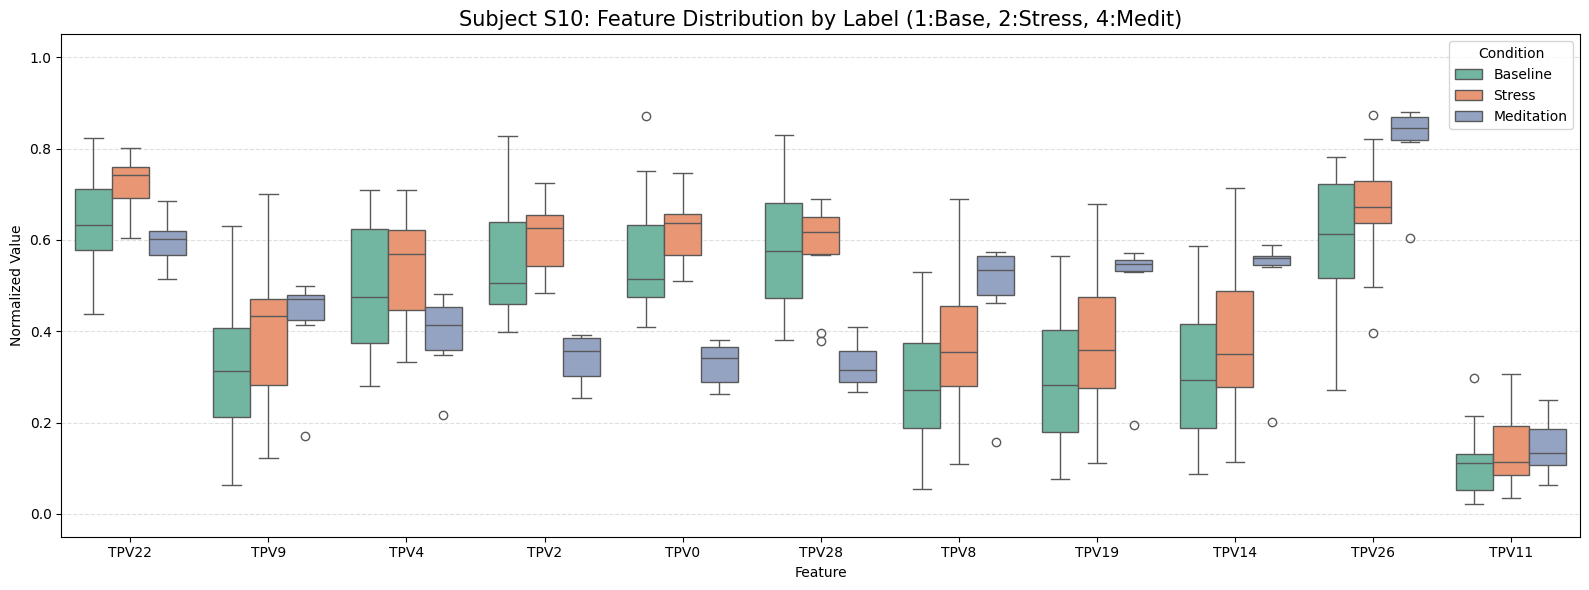

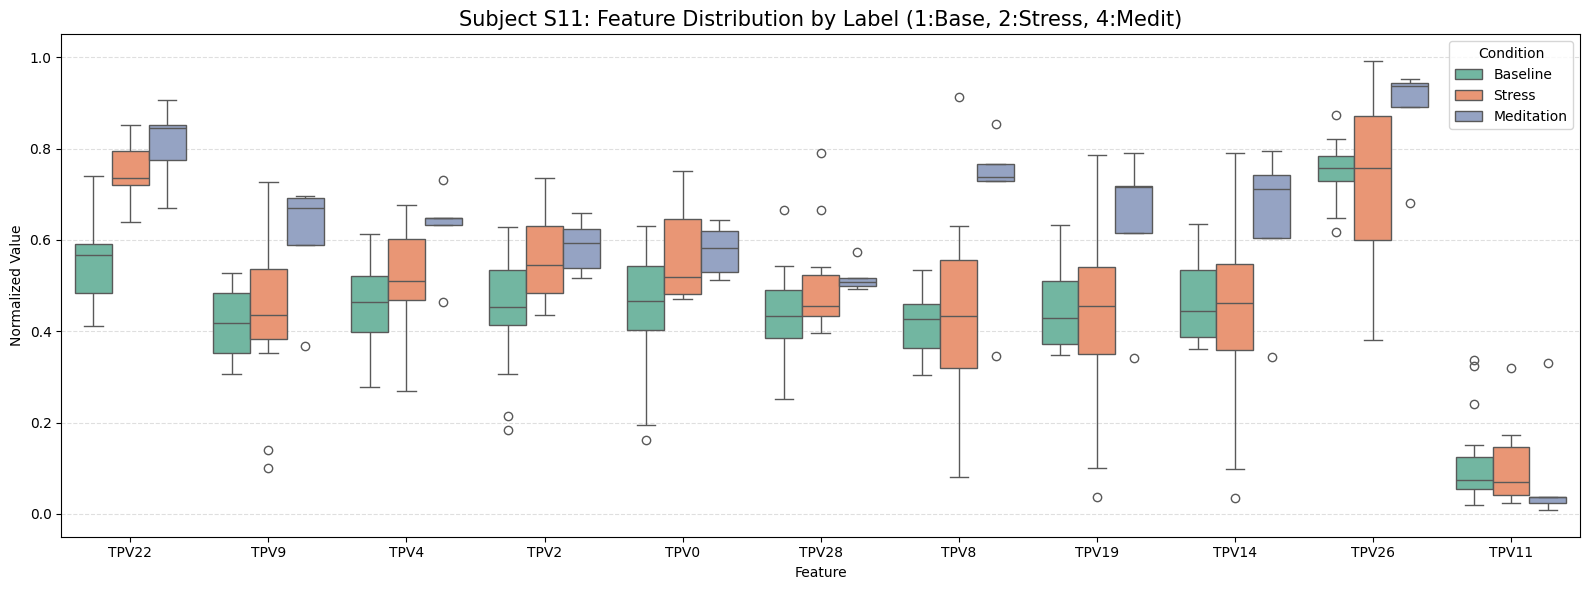

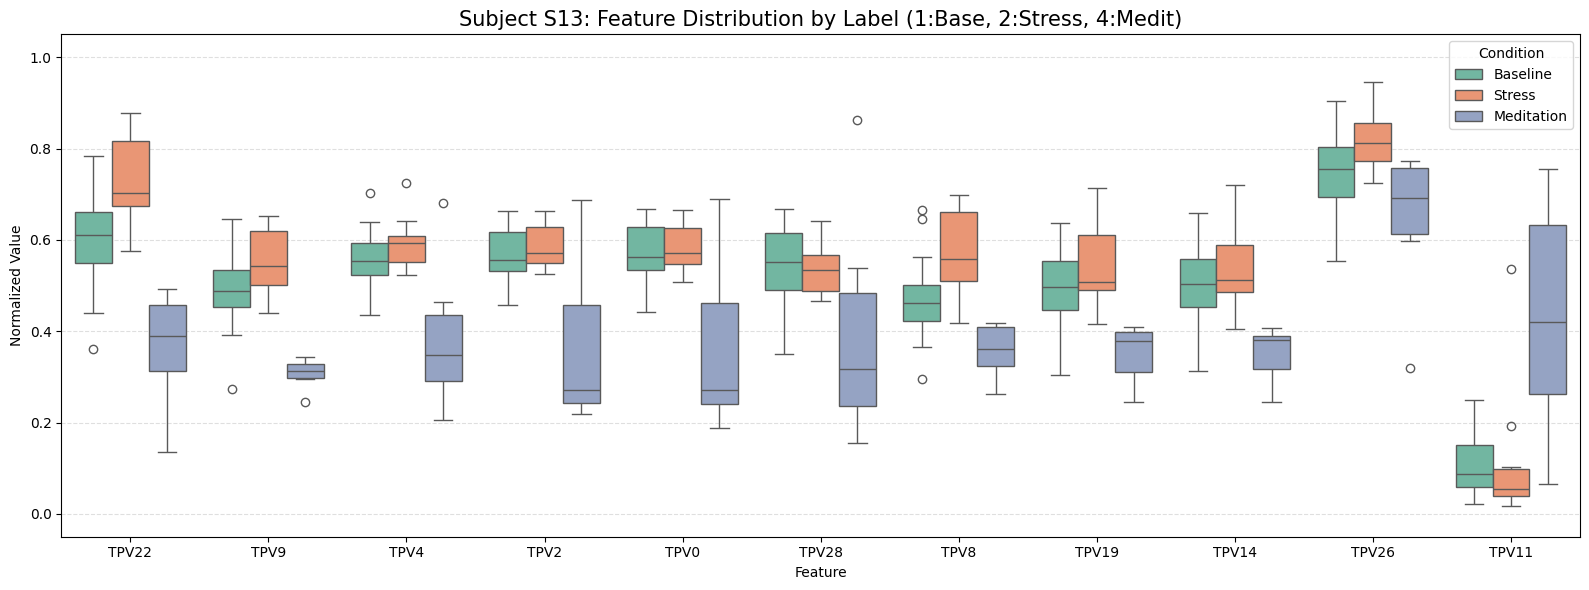

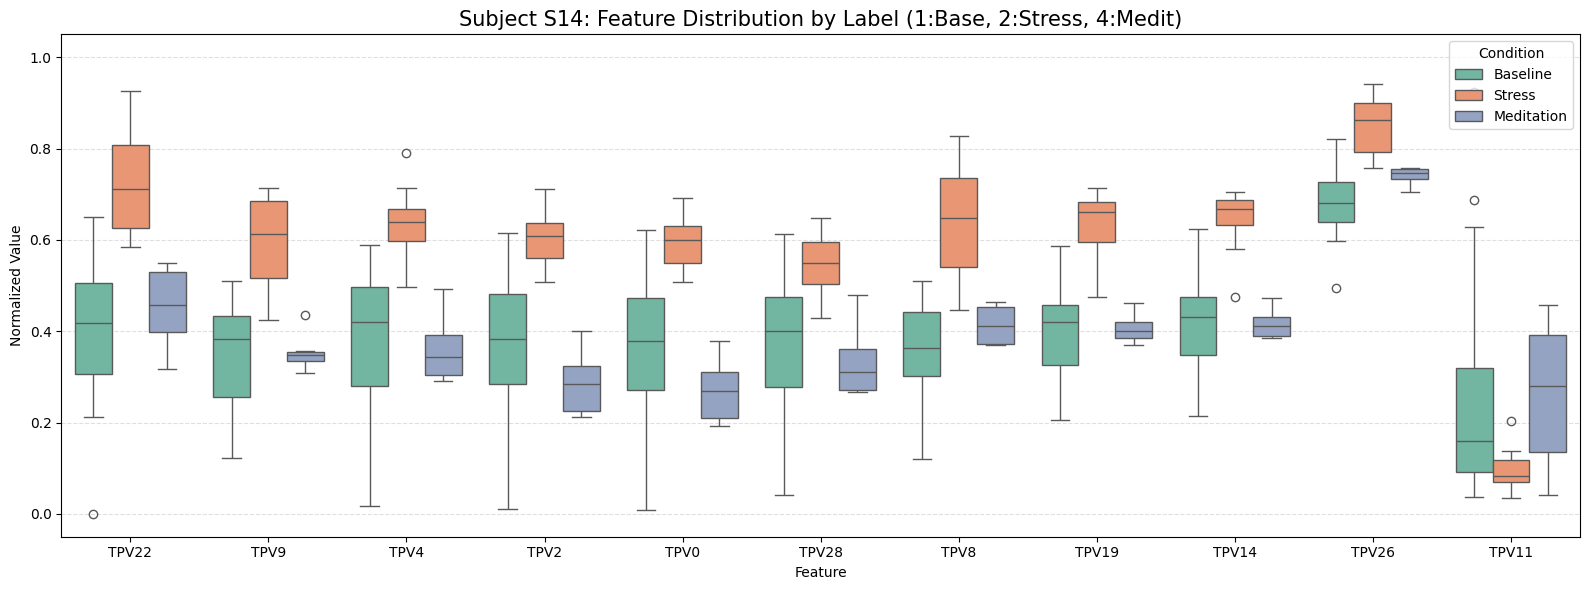

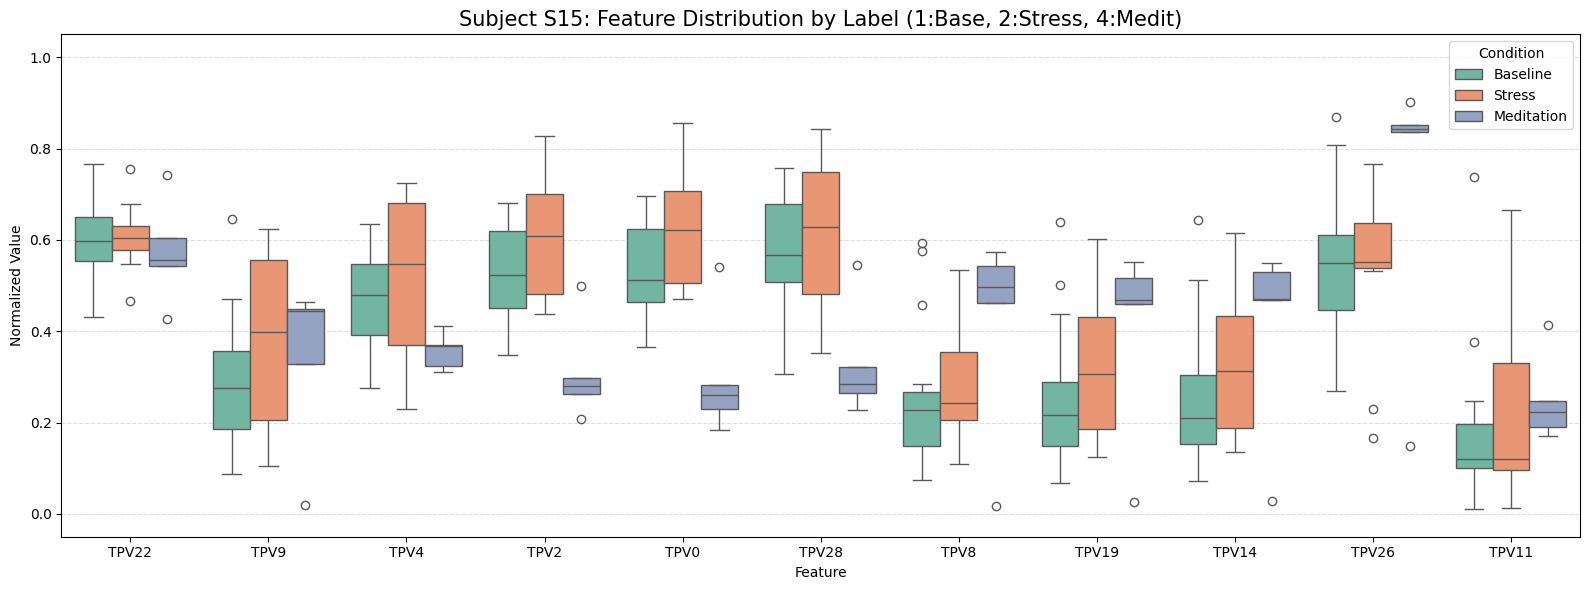

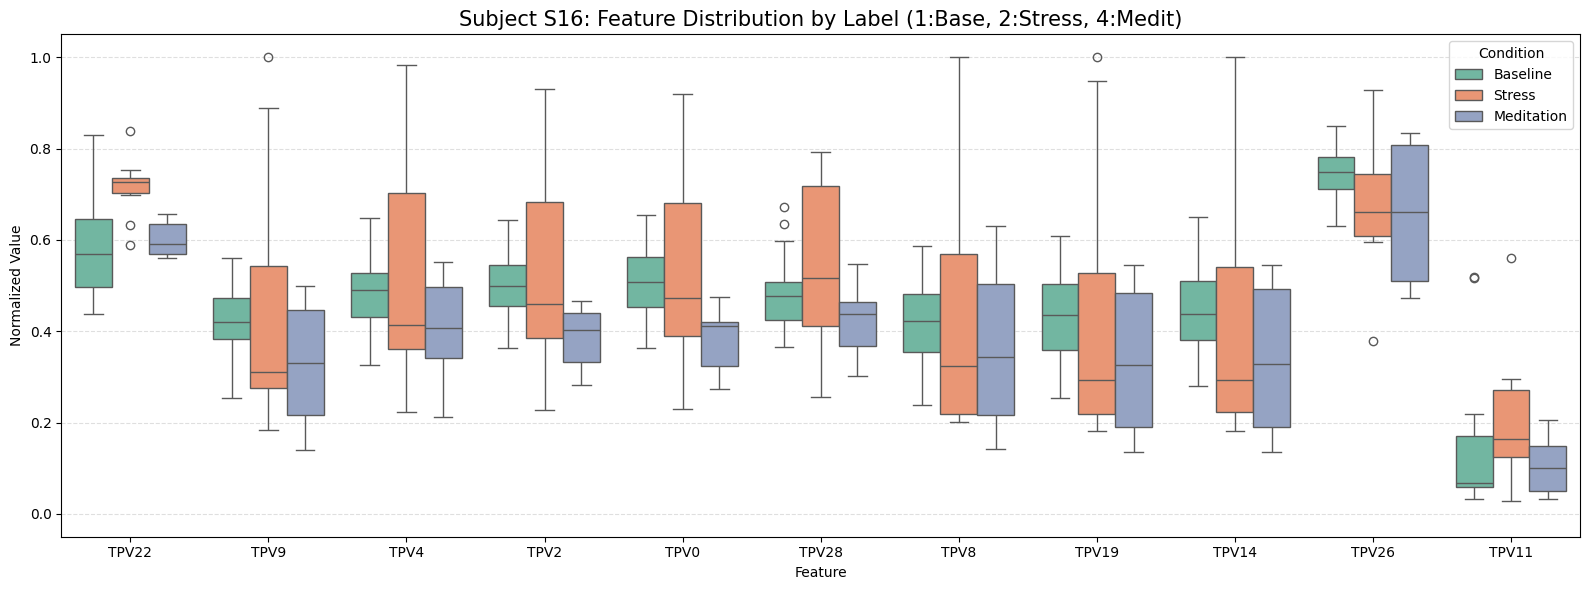

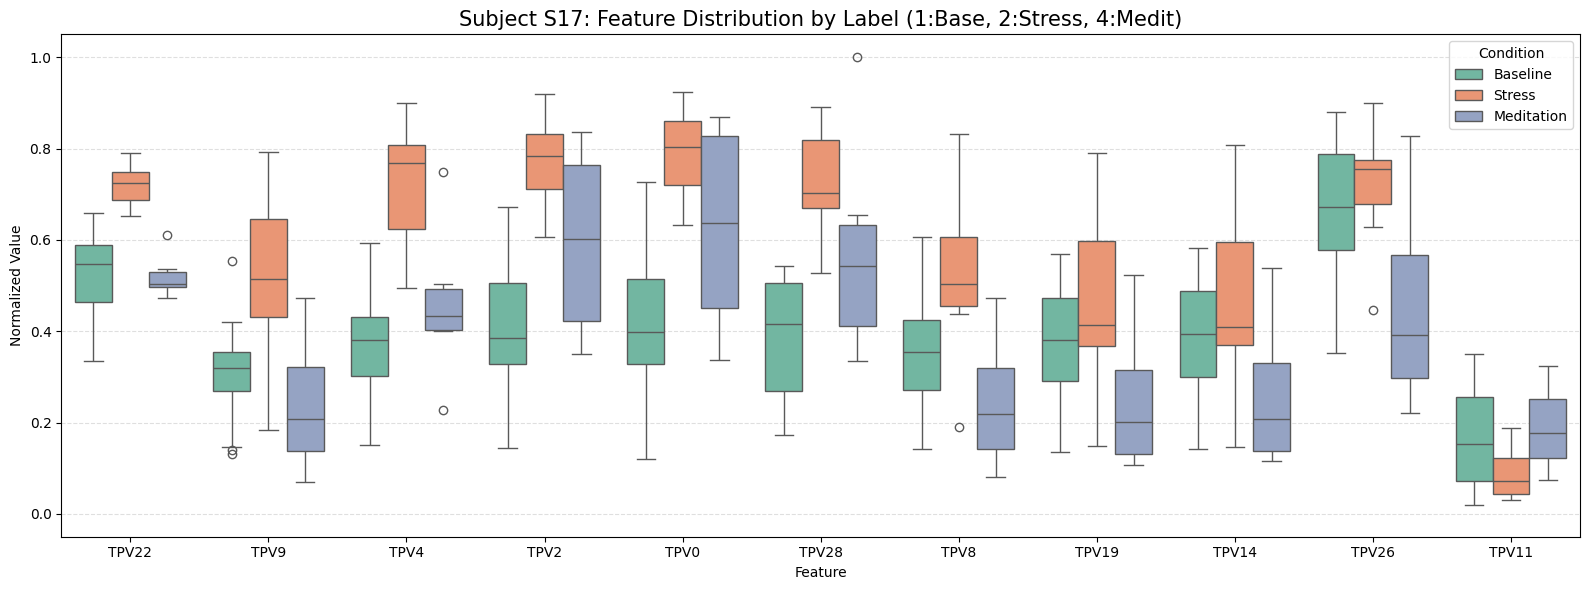

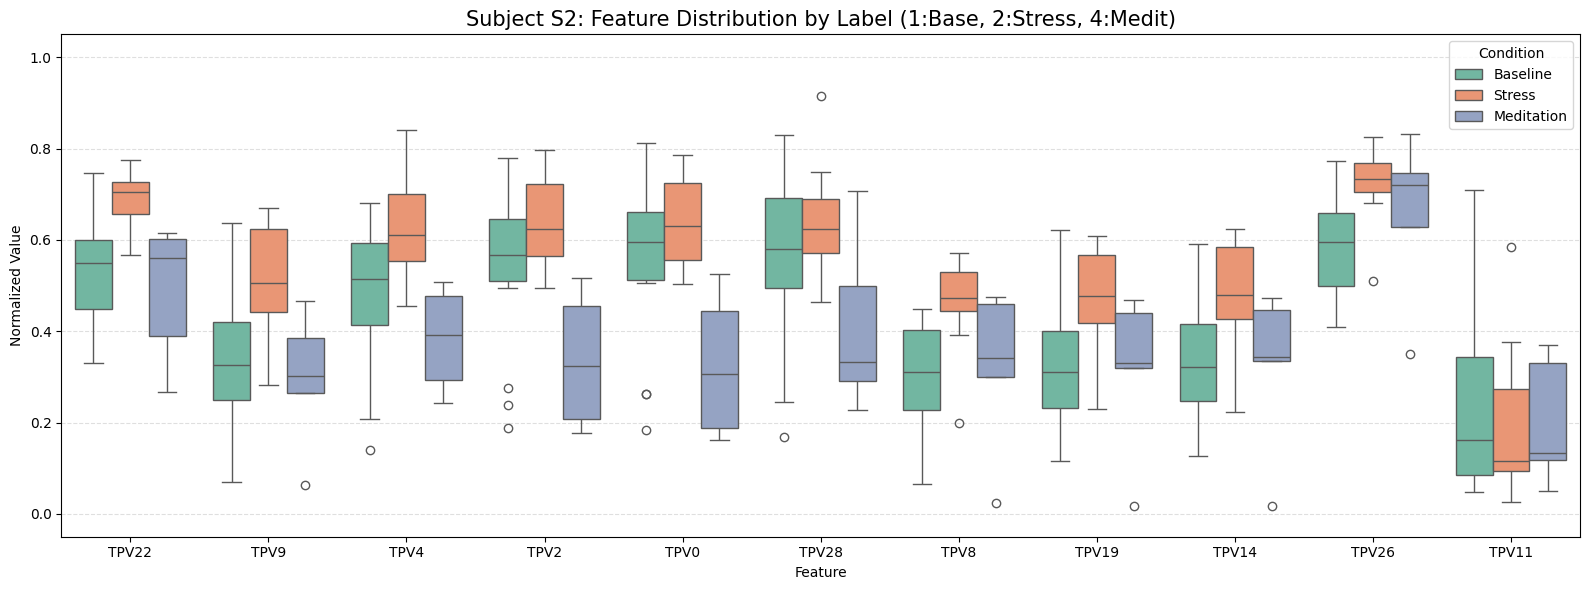

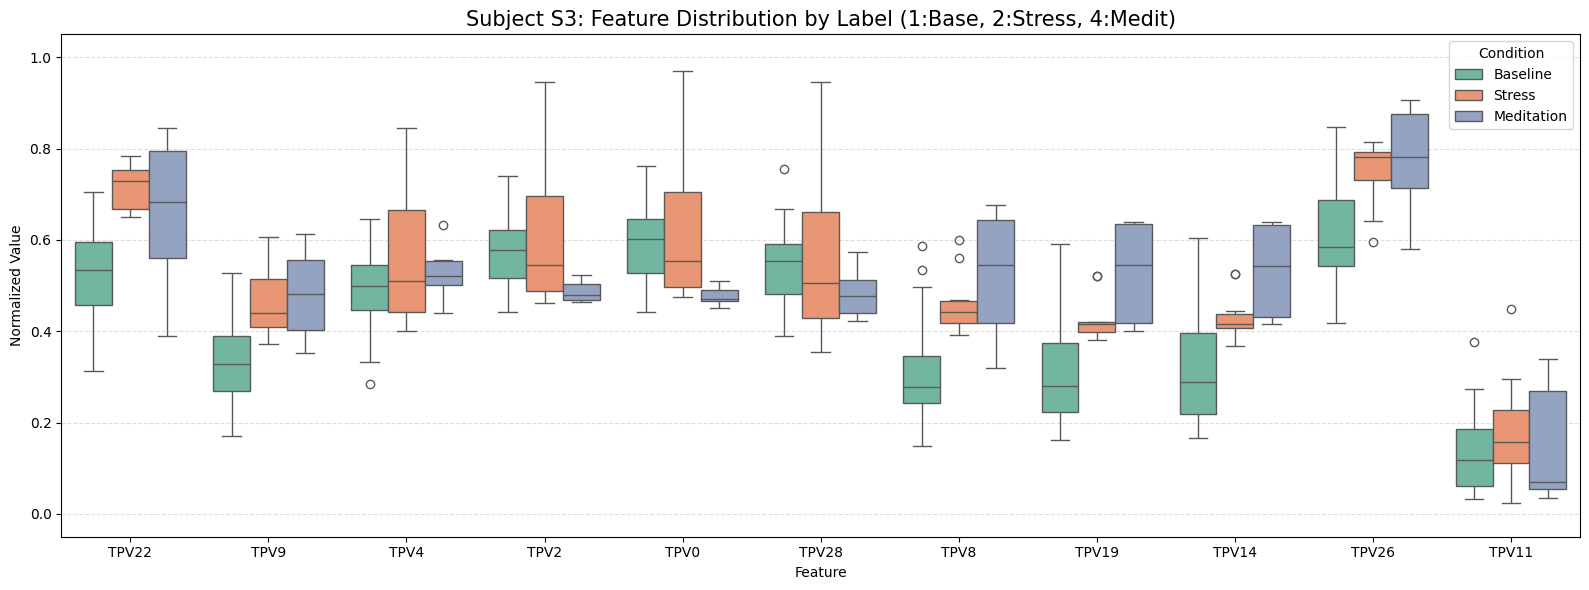

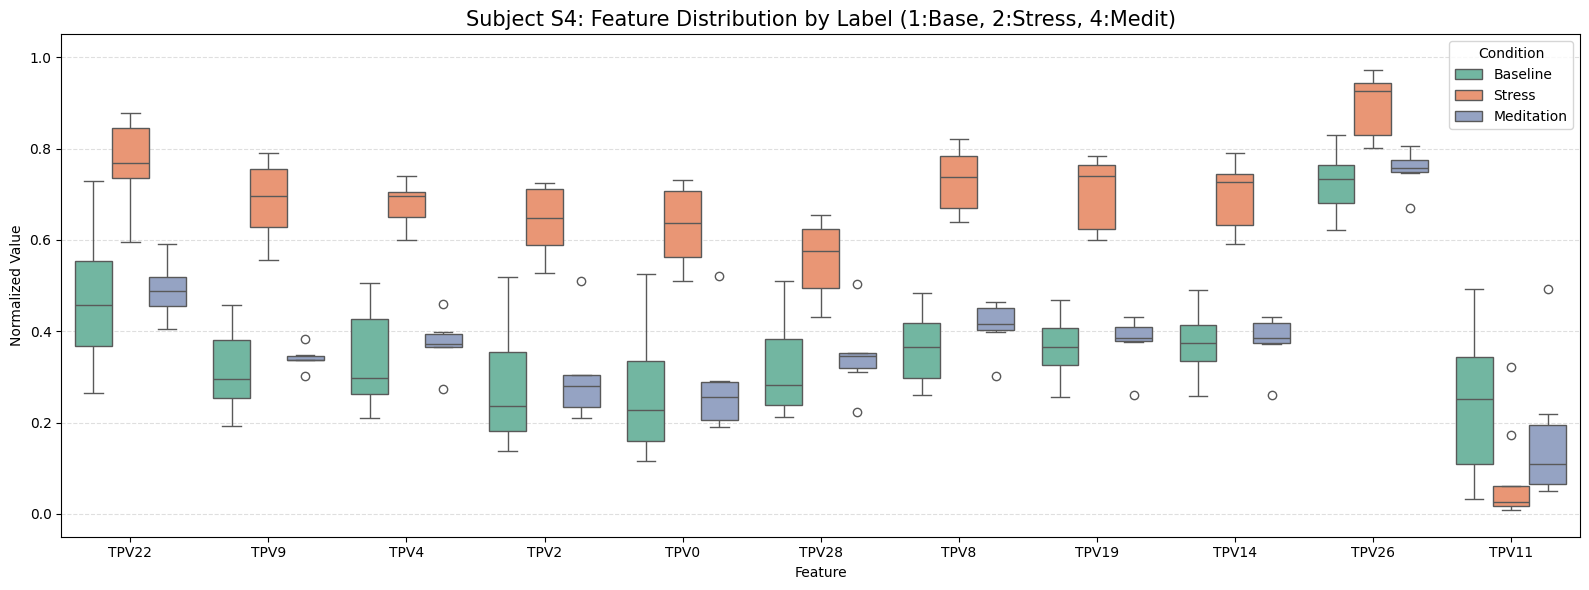

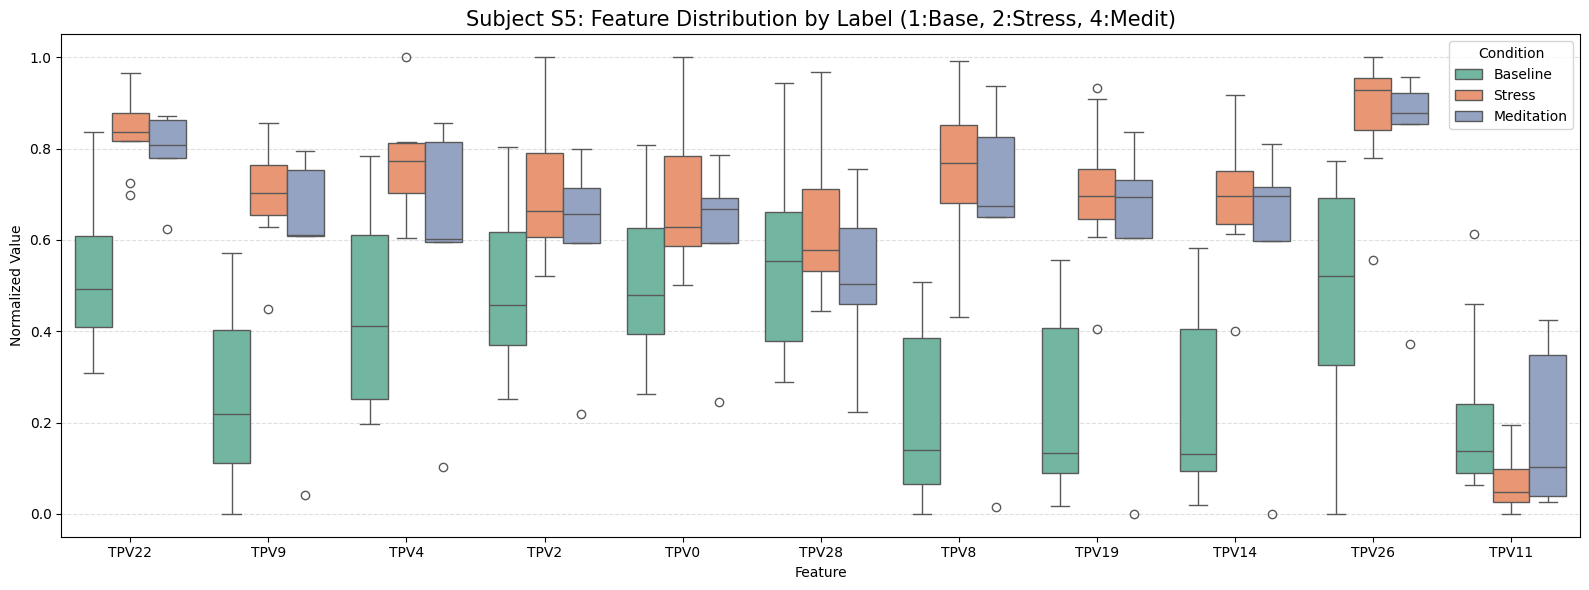

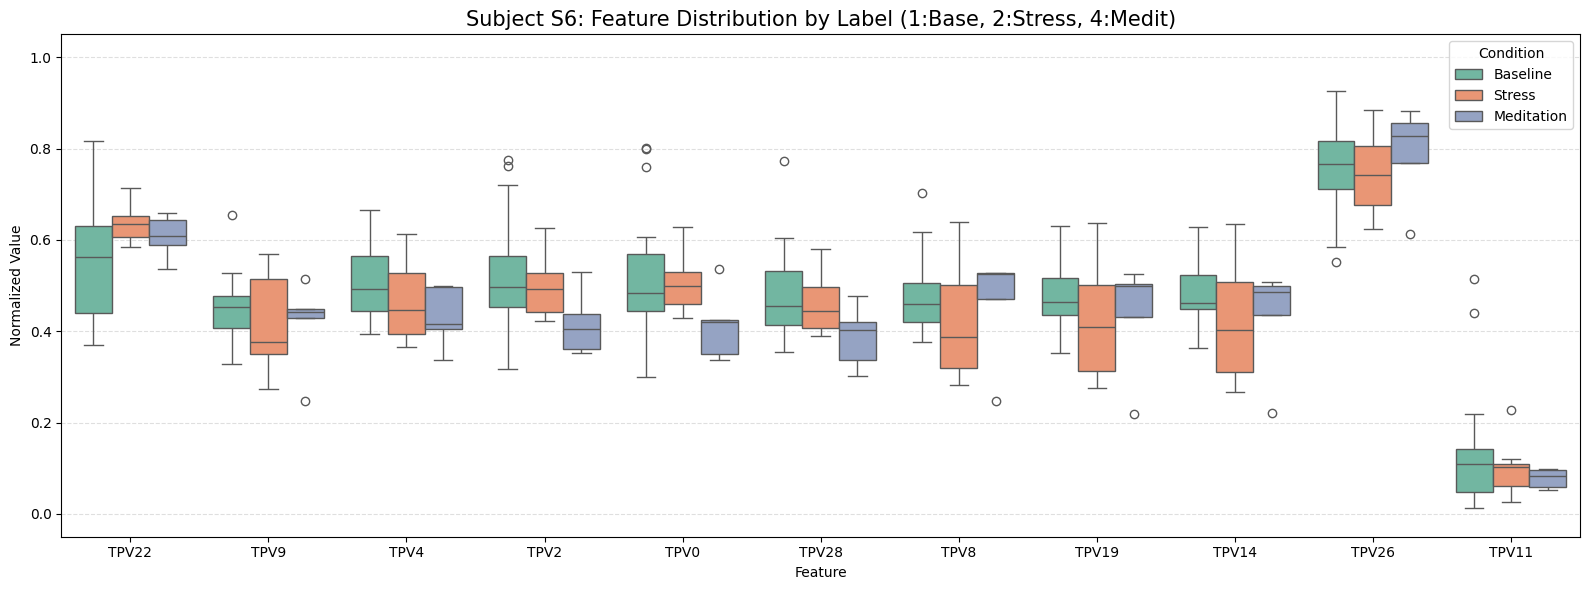

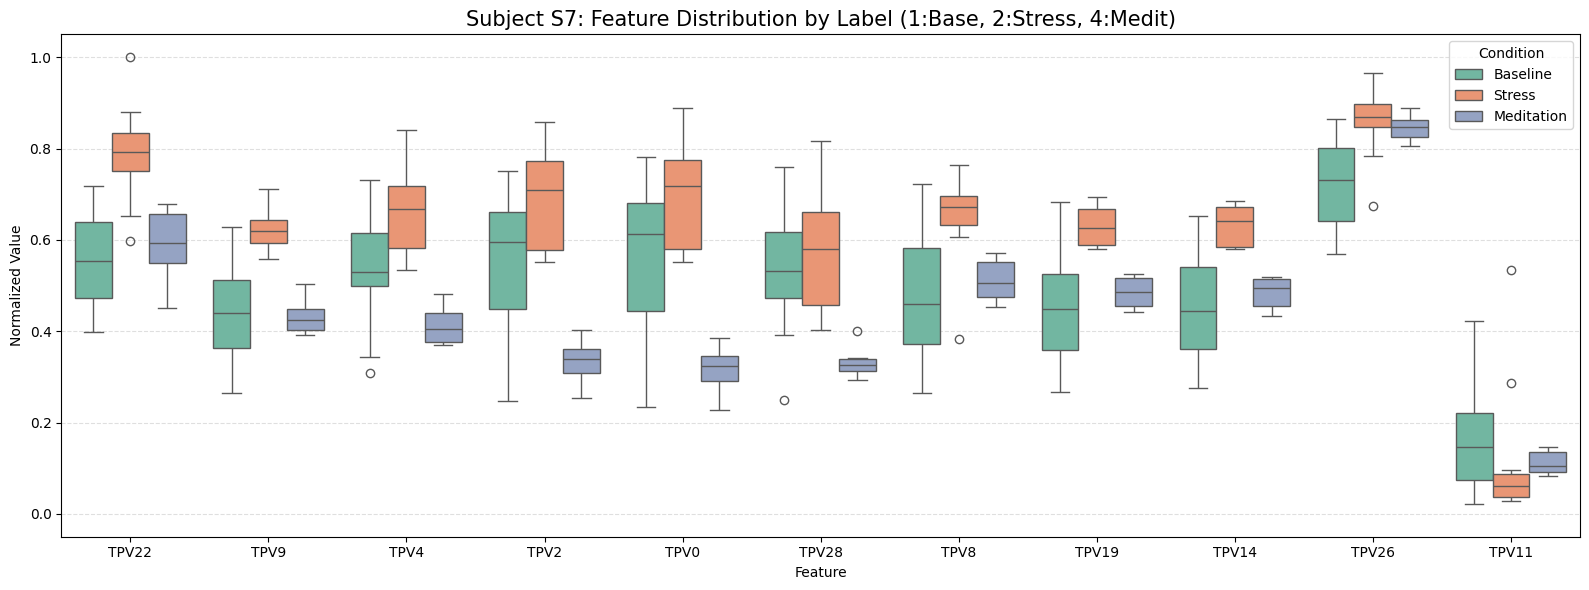

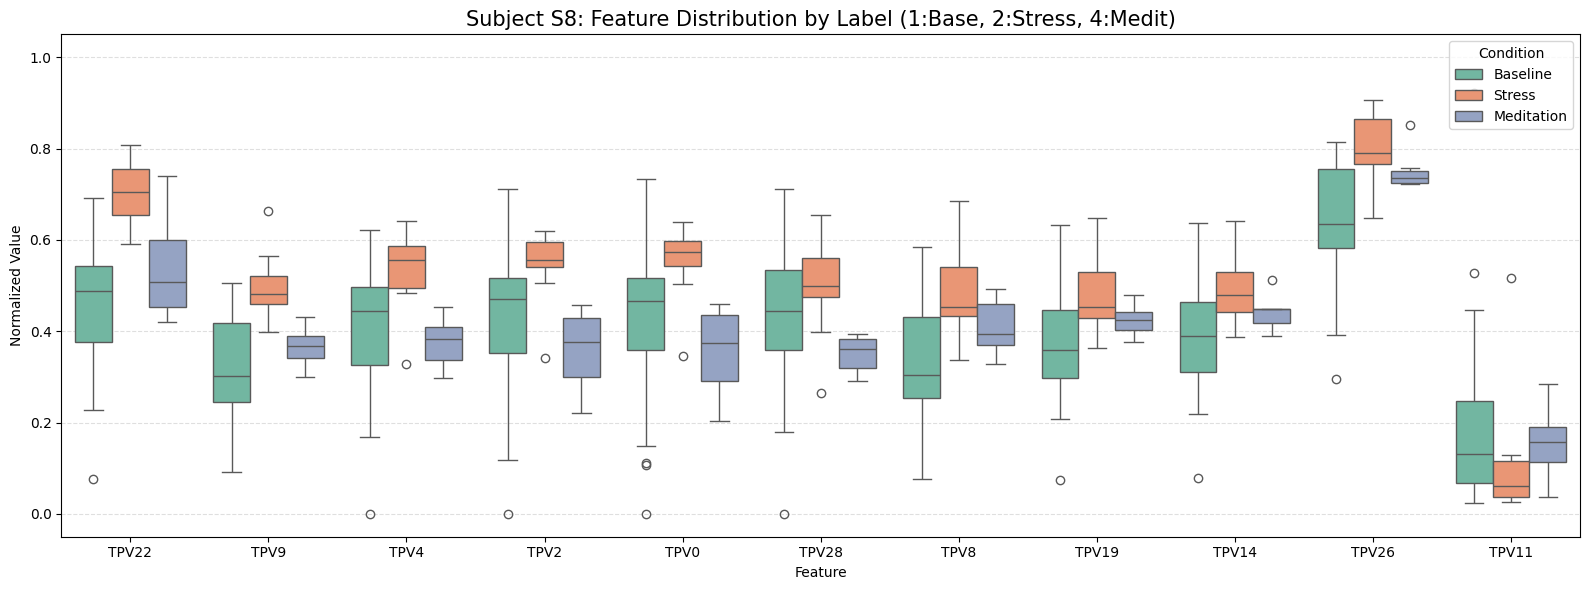

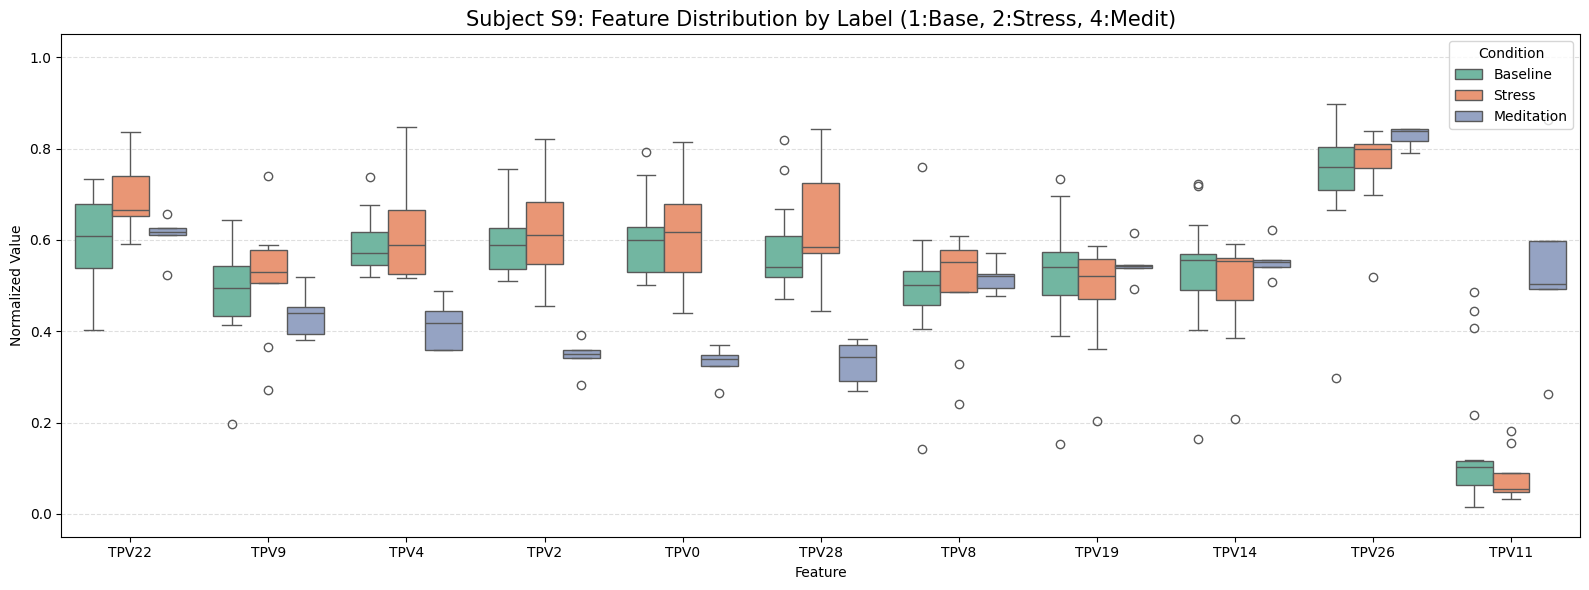

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

def plot_subject_comparison(df, features, subject_col='subject', label_col='label_major'):
    """
    사용자(Subject)별로 1(Baseline), 2(Stress), 4(Meditation) 상태의
    데이터 분포를 박스 플롯으로 시각화합니다.
    """
    # 1. 데이터 준비 및 0~1 스케일링
    plot_df = df.copy()
    scaler = MinMaxScaler()
    plot_df[features] = scaler.fit_transform(plot_df[features])

    # 라벨 매핑 (1, 2, 4 확인)
    label_map = {1: 'Baseline', 2: 'Stress', 4: 'Meditation'}
    plot_df['Condition'] = plot_df[label_col].map(label_map)

    # 1, 2, 4 데이터만 필터링 (혹시 다른 라벨이 섞여 있을 경우 대비)
    plot_df = plot_df[plot_df['Condition'].notna()]

    subjects = sorted(plot_df[subject_col].unique())

    # 2. 사용자별 그래프 생성
    for subj in subjects:
        subj_data = plot_df[plot_df[subject_col] == subj]

        # 시각화를 위해 세로로 긴 형태로 변환
        melted = subj_data.melt(id_vars=['Condition'], value_vars=features,
                               var_name='Feature', value_name='Normalized Value')

        plt.figure(figsize=(16, 6))

        # x축: 피처 종류, y축: 정규화된 값, hue: 상태(1, 2, 4)
        sns.boxplot(
            data=melted,
            x='Feature',
            y='Normalized Value',
            hue='Condition',
            palette={'Baseline': '#66c2a5', 'Stress': '#fc8d62', 'Meditation': '#8da0cb'},
            width=0.8
        )

        plt.title(f'Subject {subj}: Feature Distribution by Label (1:Base, 2:Stress, 4:Medit)', fontsize=15)
        plt.ylim(-0.05, 1.05)
        plt.legend(title='Condition', loc='upper right')
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

# 실행
plot_subject_comparison(df, TPV_COLS, SUBJECT_COL, LABEL_COL)

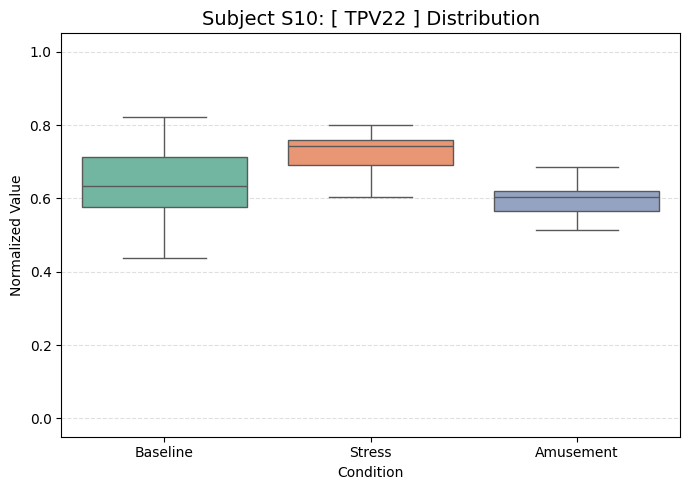

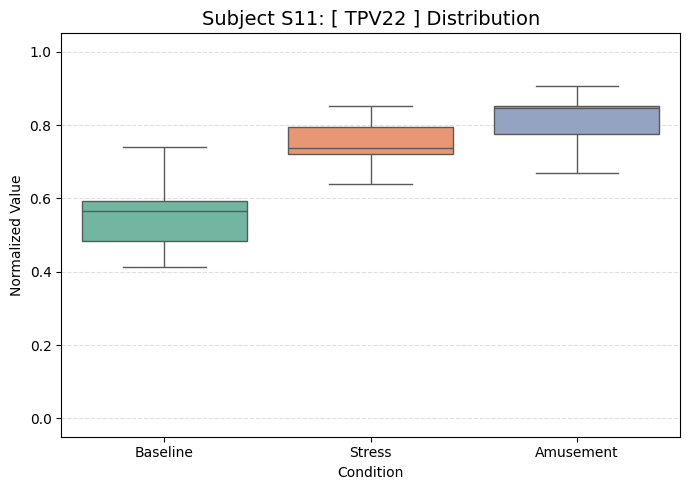

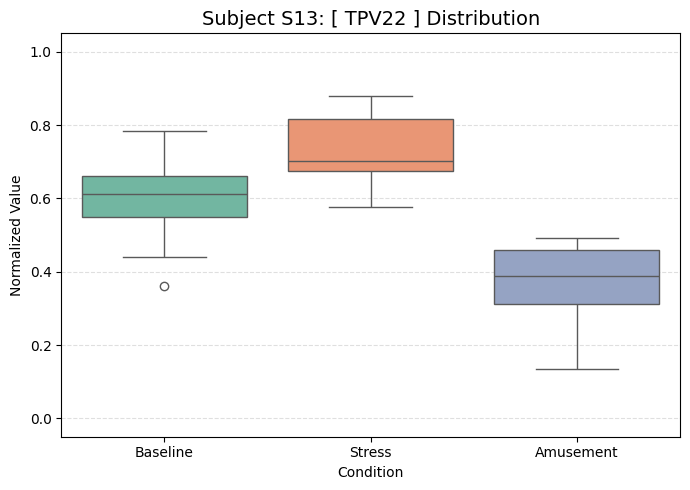

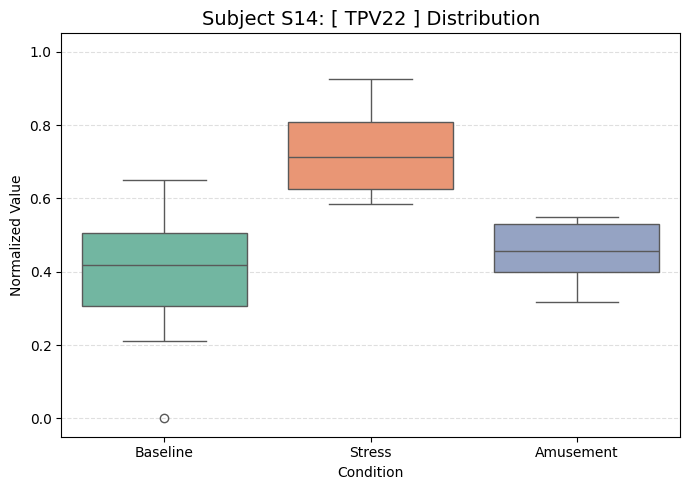

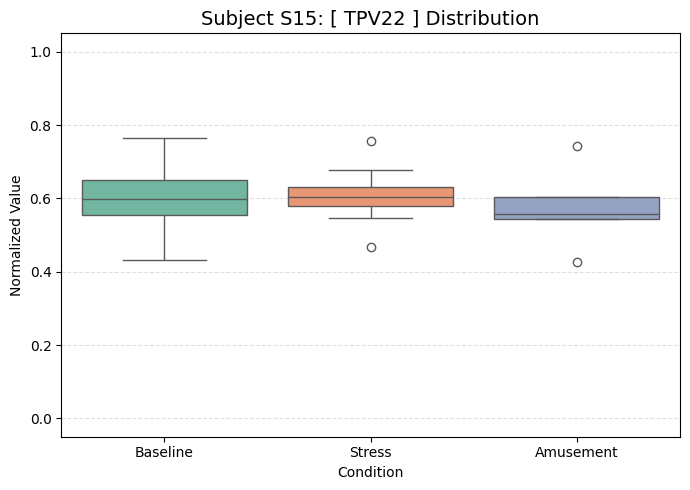

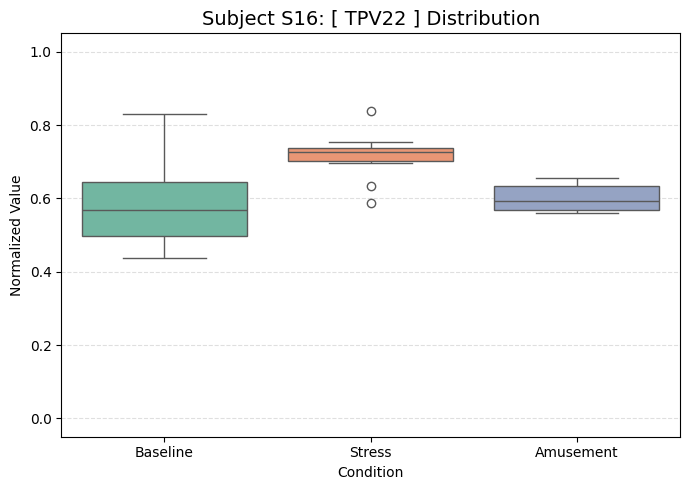

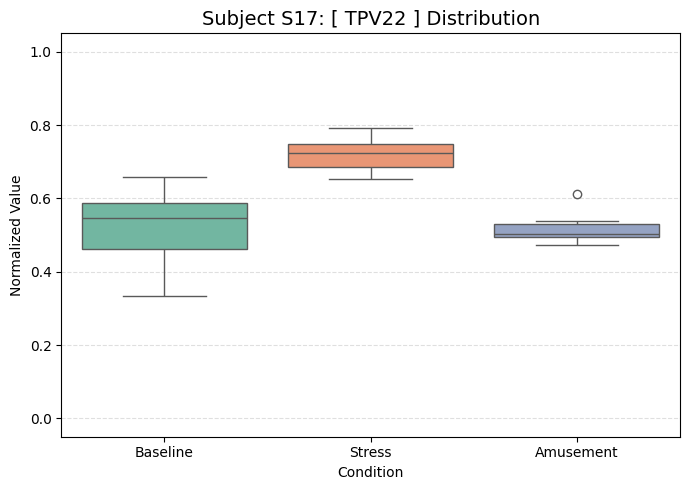

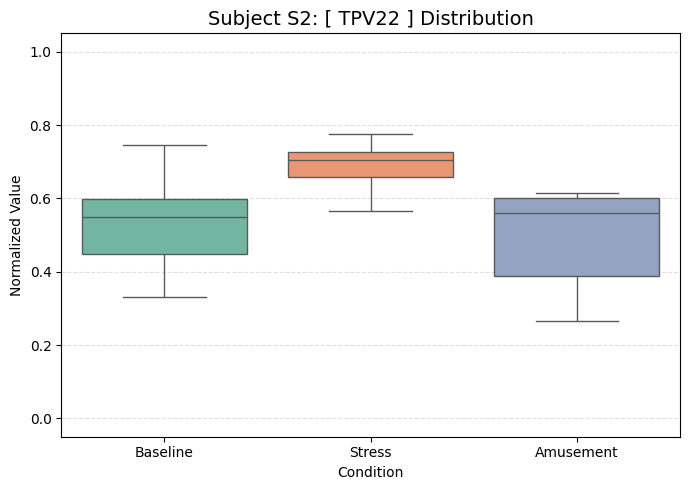

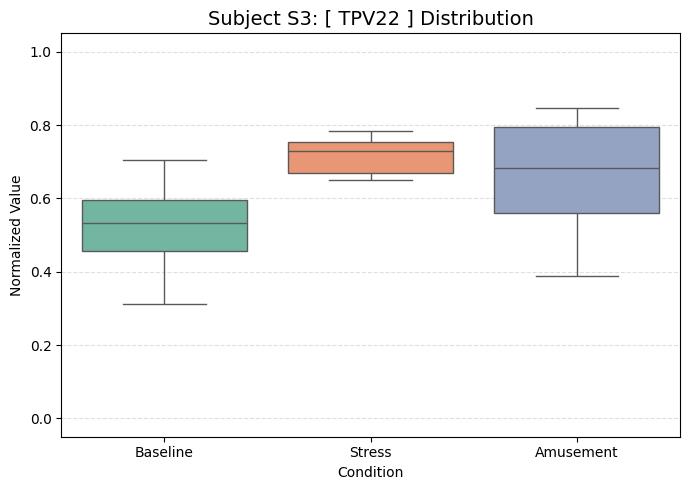

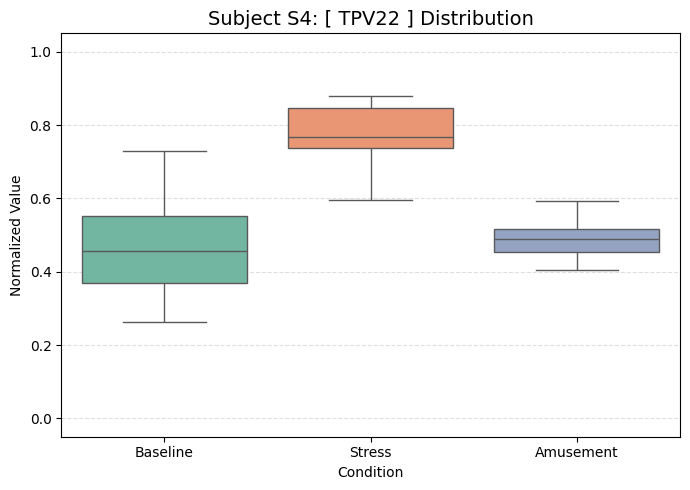

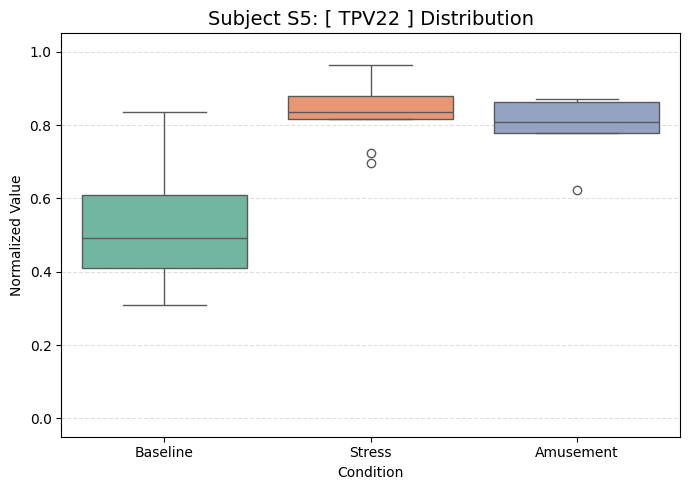

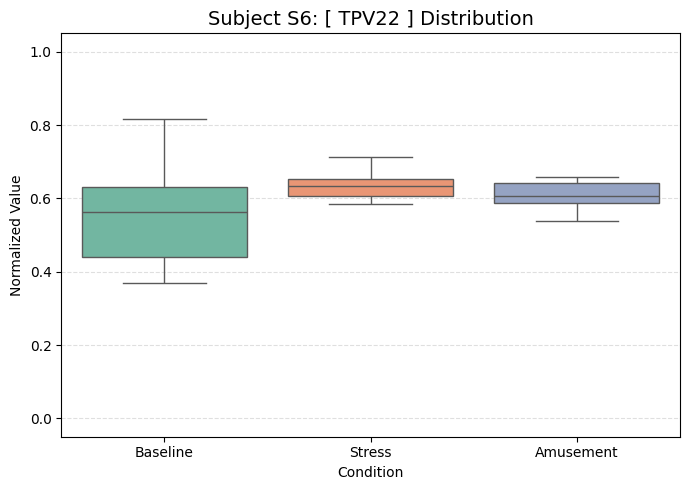

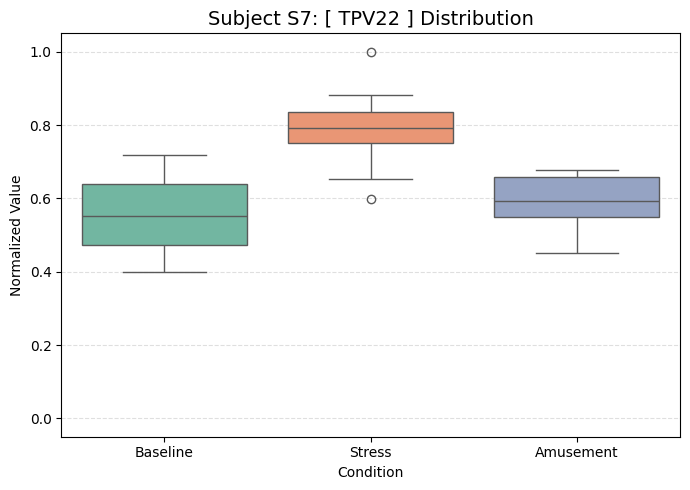

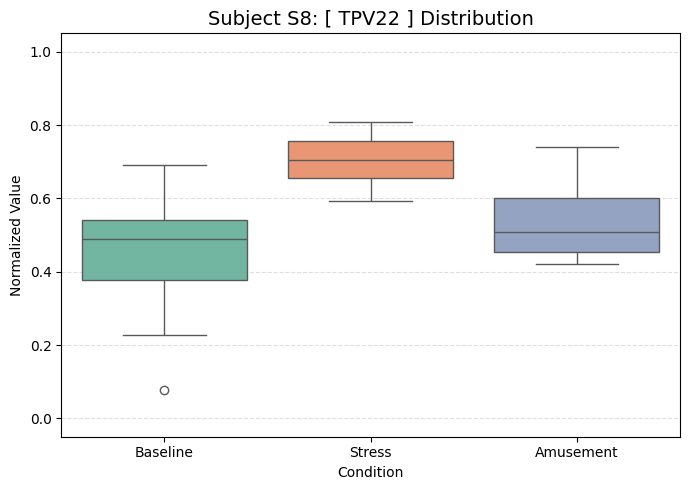

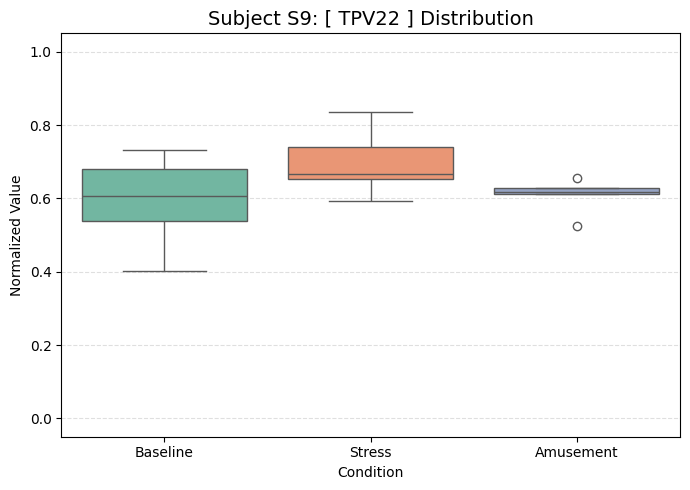

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

def plot_tpv22_only(df, subject_col='subject', label_col='label_major'):
    """
    사용자별로 TPV22 피처의 분포를 1(Base), 2(Stress), 4(Amusement) 상태별로 시각화합니다.
    """
    feature_to_plot = 'TPV22'

    # 1. 데이터 준비 및 0~1 스케일링 (비교를 위해 TPV22 값만 정규화)
    plot_df = df.copy()
    scaler = MinMaxScaler()
    plot_df[[feature_to_plot]] = scaler.fit_transform(plot_df[[feature_to_plot]])

    # 라벨 매핑 (1, 2, 4)
    label_map = {1: 'Baseline', 2: 'Stress', 4: 'Amusement'}
    plot_df['Condition'] = plot_df[label_col].map(label_map)

    # 1, 2, 4에 해당하는 데이터만 유지
    plot_df = plot_df[plot_df['Condition'].notna()]

    subjects = sorted(plot_df[subject_col].unique())

    # 2. 사용자별 루프를 돌며 그래프 생성
    for subj in subjects:
        subj_data = plot_df[plot_df[subject_col] == subj]

        plt.figure(figsize=(7, 5))

        # x축을 상태(Condition)로 설정하여 TPV22의 변화를 확인
        sns.boxplot(
            data=subj_data,
            x='Condition',
            y=feature_to_plot,
            palette={'Baseline': '#66c2a5', 'Stress': '#fc8d62', 'Amusement': '#8da0cb'},
            order=['Baseline', 'Stress', 'Amusement']
        )

        plt.title(f'Subject {subj}: [ {feature_to_plot} ] Distribution', fontsize=14)
        plt.ylim(-0.05, 1.05)  # Y축을 0~1 범위로 고정
        plt.ylabel('Normalized Value')
        plt.xlabel('Condition')
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

# 실행 (기존 코드의 df, SUBJECT_COL, LABEL_COL 활용)
plot_tpv22_only(df, SUBJECT_COL, LABEL_COL)

--- TPV22 Overall Average (Normalized) ---
   Condition     TPV22
0  Amusement  0.574223
1   Baseline  0.542610
2     Stress  0.719601
------------------------------------------


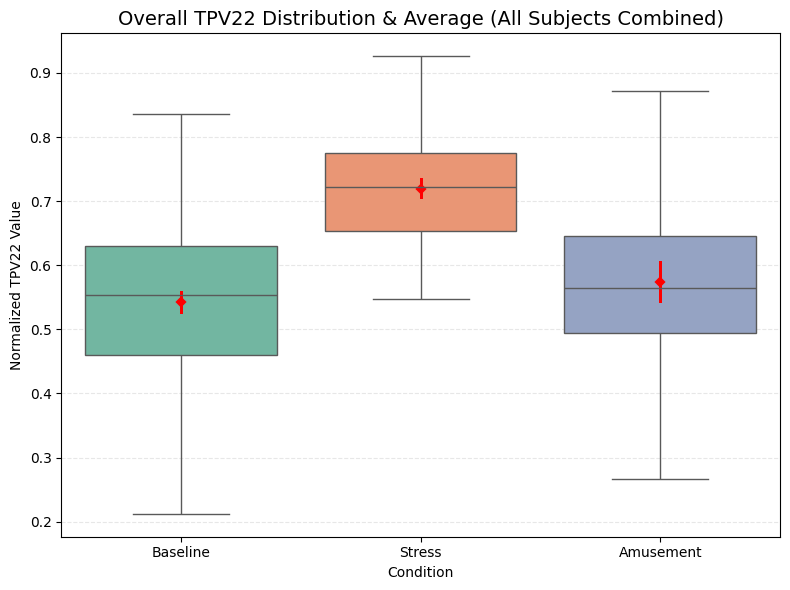

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def plot_tpv22_overall_average(df, label_col='label_major'):
    """
    모든 피험자의 데이터를 통합하여 TPV22의 라벨별(1, 2, 4) 전체 평균과 분포를 시각화합니다.
    """
    feature = 'TPV22'

    # 1. 데이터 준비 및 0~1 스케일링
    plot_df = df.copy()
    scaler = MinMaxScaler()
    plot_df[[feature]] = scaler.fit_transform(plot_df[[feature]])

    # 라벨 매핑 (1, 2, 4)
    label_map = {1: 'Baseline', 2: 'Stress', 4: 'Amusement'}
    plot_df['Condition'] = plot_df[label_col].map(label_map)
    plot_df = plot_df[plot_df['Condition'].notna()]

    # 2. 통계치 계산 (평균 확인용)
    overall_stats = plot_df.groupby('Condition')[feature].mean().reset_index()
    print("--- TPV22 Overall Average (Normalized) ---")
    print(overall_stats)
    print("------------------------------------------")

    # 3. 시각화 (박스 플롯 + 평균값 표시)
    plt.figure(figsize=(8, 6))

    # 전체 분포를 보여주는 박스 플롯
    sns.boxplot(
        data=plot_df,
        x='Condition',
        y=feature,
        palette={'Baseline': '#66c2a5', 'Stress': '#fc8d62', 'Amusement': '#8da0cb'},
        order=['Baseline', 'Stress', 'Amusement'],
        showfliers=False  # 이상치는 제외하고 박스 위주로 표시 (깔끔하게 보기 위함)
    )

    # 평균값을 별도의 점으로 표시 (빨간색 다이아몬드)
    sns.pointplot(
        data=plot_df,
        x='Condition',
        y=feature,
        color='red',
        markers='D',
        scale=0.8,
        order=['Baseline', 'Stress', 'Amusement'],
        join=False
    )

    plt.title('Overall TPV22 Distribution & Average (All Subjects Combined)', fontsize=14)
    plt.ylabel('Normalized TPV22 Value')
    plt.xlabel('Condition')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 실행
plot_tpv22_overall_average(df, LABEL_COL)


 Task: Binary (Base vs Stress) (2-Class)
[XGBoost     ] Acc: 0.7742 | F1-Macro: 0.7471
[RandomForest] Acc: 0.7673 | F1-Macro: 0.7333
[SVM         ] Acc: 0.7788 | F1-Macro: 0.7450
[MLP         ] Acc: 0.7604 | F1-Macro: 0.7298


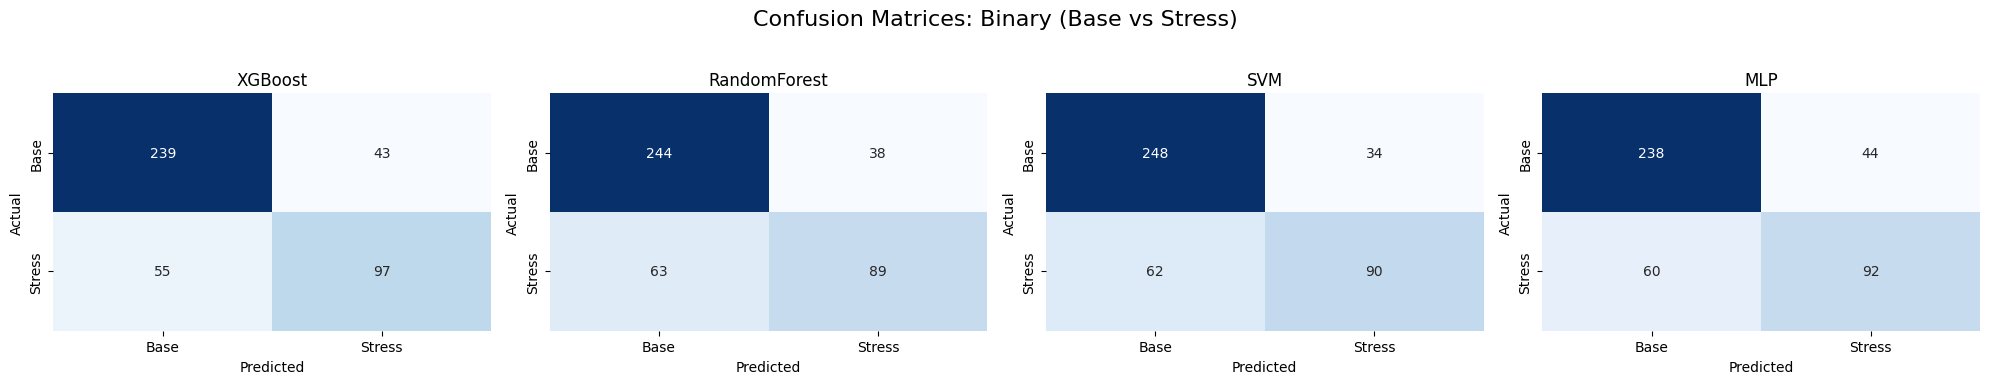


 Task: 3-Class (Base vs Stress vs Amuse) (3-Class)
[XGBoost     ] Acc: 0.6737 | F1-Macro: 0.6259
[RandomForest] Acc: 0.6834 | F1-Macro: 0.6287
[SVM         ] Acc: 0.6853 | F1-Macro: 0.6067
[MLP         ] Acc: 0.6313 | F1-Macro: 0.5615


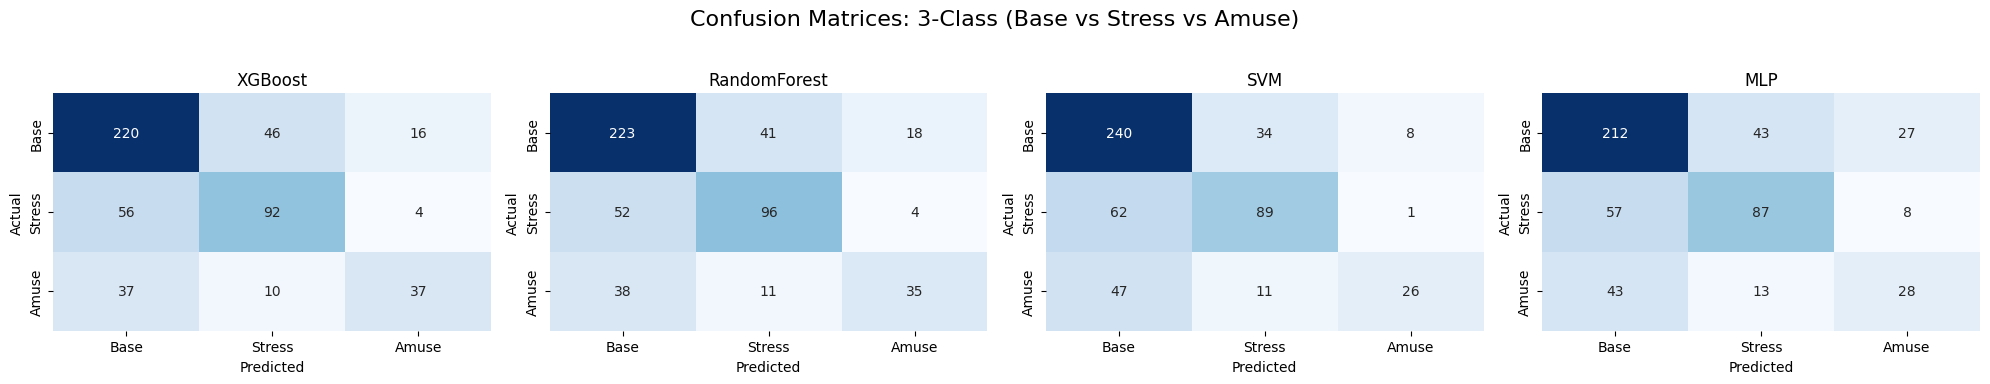

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# ==========================================
# 1. 설정 및 모델 정의
# ==========================================
TPV_COLS = ['TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']
LABEL_COL = 'label_major'
SUBJECT_COL = 'subject'

def get_models(num_classes):
    """4가지 모델을 정의하여 반환합니다."""
    # 2진 분류와 3진 분류에 따라 XGBoost의 objective 설정이 달라질 수 있음
    objective = 'binary:logistic' if num_classes == 2 else 'multi:softprob'

    return {
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                 objective=objective, random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
        'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, alpha=1e-4,
                             solver='adam', random_state=42)
    }

# ==========================================
# 2. LOSO 평가 함수
# ==========================================
def run_loso_evaluation(data, task_name, class_names):
    """데이터에 대해 LOSO 방식으로 4개 모델을 평가하고 혼동행렬을 출력합니다."""
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    # 결과 저장용
    final_results = {}

    print(f"\n{'='*60}")
    print(f" Task: {task_name} ({num_classes}-Class)")
    print(f"{'='*60}")

    # 모델별 루프
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'Confusion Matrices: {task_name}', fontsize=16)

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        # LOSO Cross-Validation
        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj]
            test_df = data[data[SUBJECT_COL] == test_subj]

            X_train, y_train = train_df[TPV_COLS], train_df['target']
            X_test, y_test = test_df[TPV_COLS], test_df['target']

            # 스케일링
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # 학습 및 예측
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        # 성능 집계
        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average='macro')
        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")

        # 혼동행렬 시각화
        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                    xticklabels=class_names, yticklabels=class_names)
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ==========================================
# 3. 메인 실행 루프 (2진 및 3진 분류)
# ==========================================
# 데이터 로드 (df가 이미 로드되어 있다고 가정)
# df = pd.read_csv('WESAD-TPV-NoQC.csv')

# --- 시나리오 1: 2진 분류 (1: Baseline vs 2: Stress) ---
df_bin = df[df[LABEL_COL].isin([1, 2])].copy()
le_bin = LabelEncoder()
df_bin['target'] = le_bin.fit_transform(df_bin[LABEL_COL]) # 1->0, 2->1
run_loso_evaluation(df_bin, "Binary (Base vs Stress)", ['Base', 'Stress'])

# --- 시나리오 2: 3진 분류 (1: Base, 2: Stress, 4: Amusement) ---
df_tri = df[df[LABEL_COL].isin([1, 2, 4])].copy()
le_tri = LabelEncoder()
df_tri['target'] = le_tri.fit_transform(df_tri[LABEL_COL]) # 1->0, 2->1, 4->2
run_loso_evaluation(df_tri, "3-Class (Base vs Stress vs Amuse)", ['Base', 'Stress', 'Amuse'])

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

def run_personalized_model(df, features, target_col='label_major', subject_col='subject'):
    """
    각 사용자별로 독립된 모델을 학습시켜 개인화된 성능을 측정합니다.
    """
    subjects = sorted(df[subject_col].unique())
    results = []

    print(f"{'Subject':<10} | {'Train Size':<12} | {'Test Size':<12} | {'Accuracy':<10} | {'F1-Macro':<10}")
    print("-" * 70)

    for subj in subjects:
        # 1. 특정 사용자의 데이터만 추출
        subj_df = df[df[subject_col] == subj].copy()

        # 2. 1, 2, 4 라벨만 사용 (3진 분류)
        subj_df = subj_df[subj_df[target_col].isin([1, 2, 4])]

        X = subj_df[features]
        y = subj_df[target_col].map({1: 0, 2: 1, 4: 2}) # 0, 1, 2로 인코딩

        # 데이터가 너무 적으면 분할 불가하므로 체크
        if len(subj_df) < 10:
            continue

        # 3. 해당 사용자의 데이터를 Train/Test로 분할 (개인화 핵심)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # 4. 스케일링
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # 5. 모델 학습 (개인 전용 모델)
        model = XGBClassifier(
            n_estimators=50,
            learning_rate=0.1,
            max_depth=3,
            objective='multi:softprob',
            random_state=42,
            eval_metric='mlogloss'
        )
        model.fit(X_train, y_train)

        # 6. 예측 및 평가
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')

        results.append({'subject': subj, 'acc': acc, 'f1': f1})
        print(f"{subj:<10} | {len(X_train):<12} | {len(X_test):<12} | {acc:<10.4f} | {f1:<10.4f}")

    # 전체 평균 출력
    avg_acc = np.mean([r['acc'] for r in results])
    avg_f1 = np.mean([r['f1'] for r in results])
    print("-" * 70)
    print(f"{'OVERALL AVG':<39} | {avg_acc:<10.4f} | {avg_f1:<10.4f}")

    return pd.DataFrame(results)

# 실행 (기존 df와 TPV_COLS 사용)
perf_df = run_personalized_model(df, TPV_COLS, LABEL_COL, SUBJECT_COL)

Subject    | Train Size   | Test Size    | Accuracy   | F1-Macro  
----------------------------------------------------------------------
S10        | 28           | 8            | 0.7500     | 0.8056    
S11        | 28           | 7            | 0.7143     | 0.5185    
S13        | 28           | 7            | 0.5714     | 0.5794    
S14        | 28           | 7            | 0.8571     | 0.6296    
S15        | 28           | 7            | 0.5714     | 0.6571    
S16        | 28           | 7            | 0.7143     | 0.5079    
S17        | 28           | 8            | 0.8750     | 0.9048    
S2         | 26           | 7            | 0.7143     | 0.4889    
S3         | 27           | 7            | 0.7143     | 0.4889    
S4         | 27           | 7            | 0.7143     | 0.5833    
S5         | 26           | 7            | 0.4286     | 0.2222    
S6         | 27           | 7            | 1.0000     | 1.0000    
S7         | 28           | 7            | 0.7143     | 0.


[실행 중] Binary-Class (LOSO Evaluation)...
 - XGBoost     : Acc=0.7742, F1=0.7471


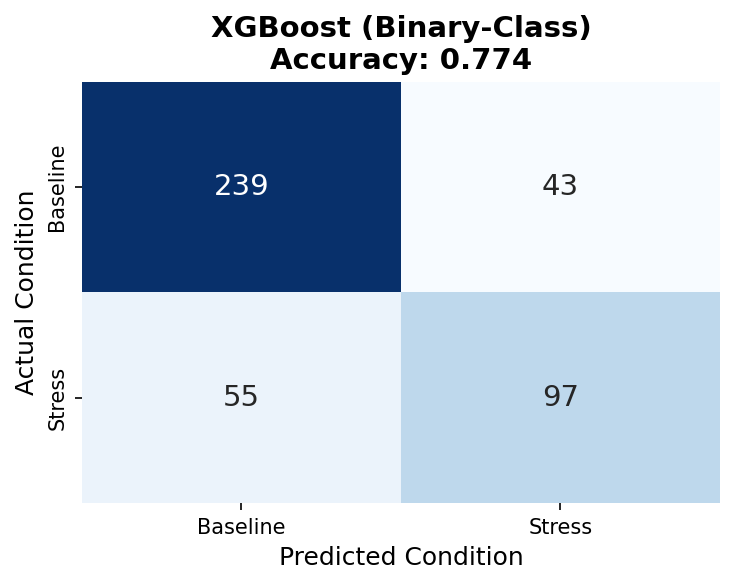

 - RandomForest: Acc=0.7673, F1=0.7333


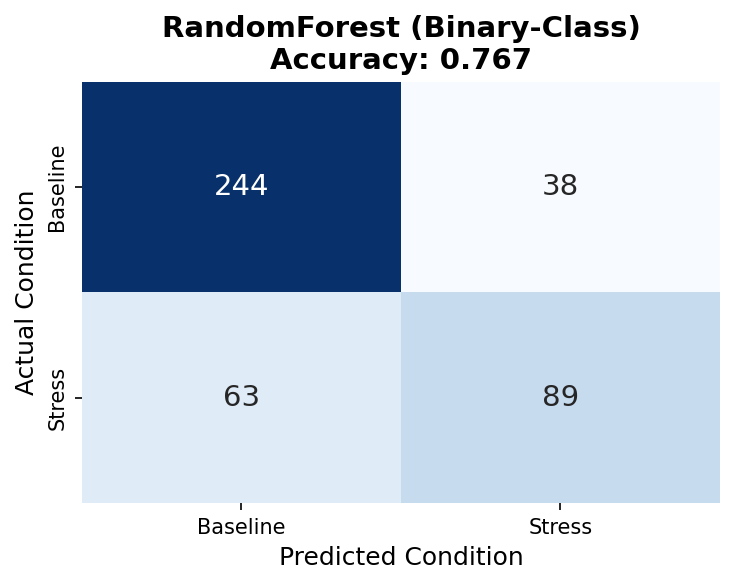

 - SVM         : Acc=0.7788, F1=0.7450


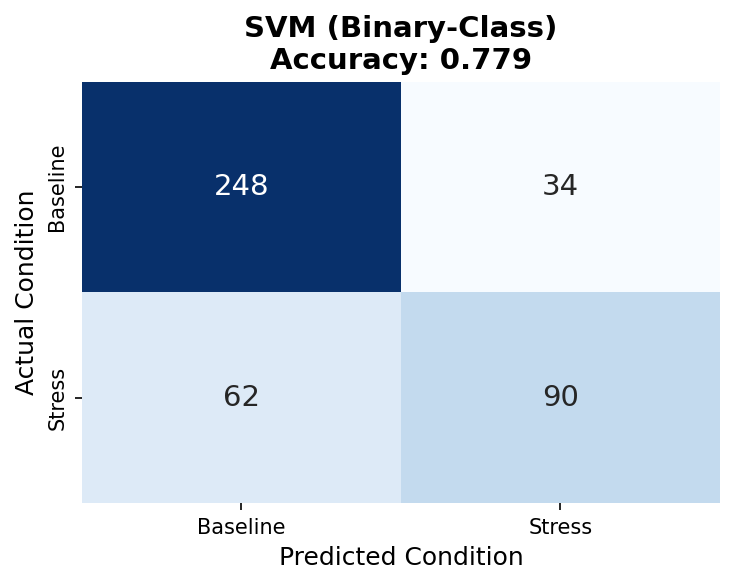

 - MLP         : Acc=0.7604, F1=0.7298


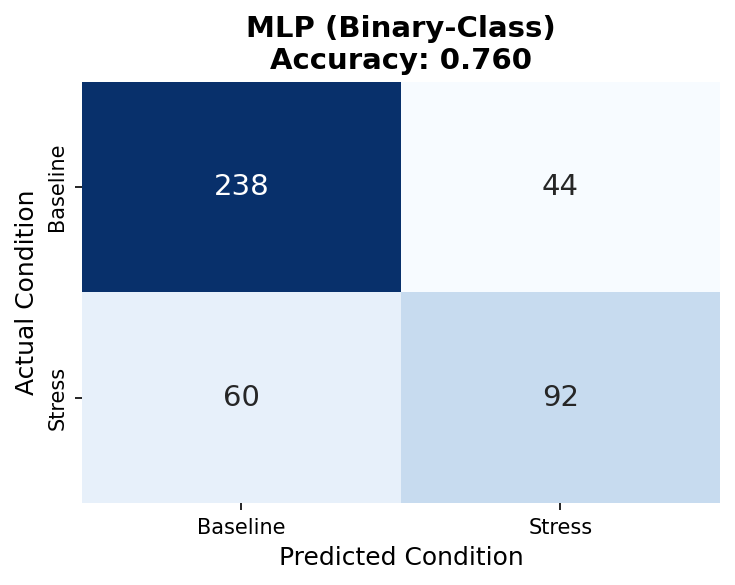


[실행 중] 3-Class (LOSO Evaluation)...
 - XGBoost     : Acc=0.6737, F1=0.6259


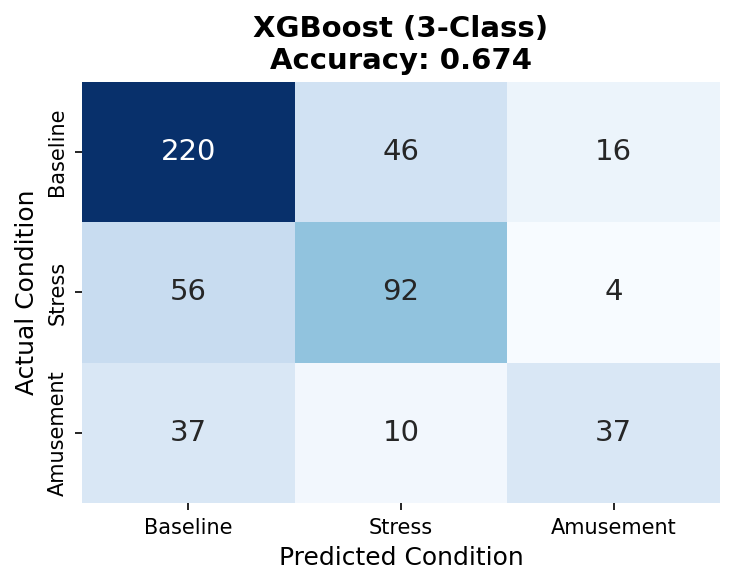

 - RandomForest: Acc=0.6834, F1=0.6287


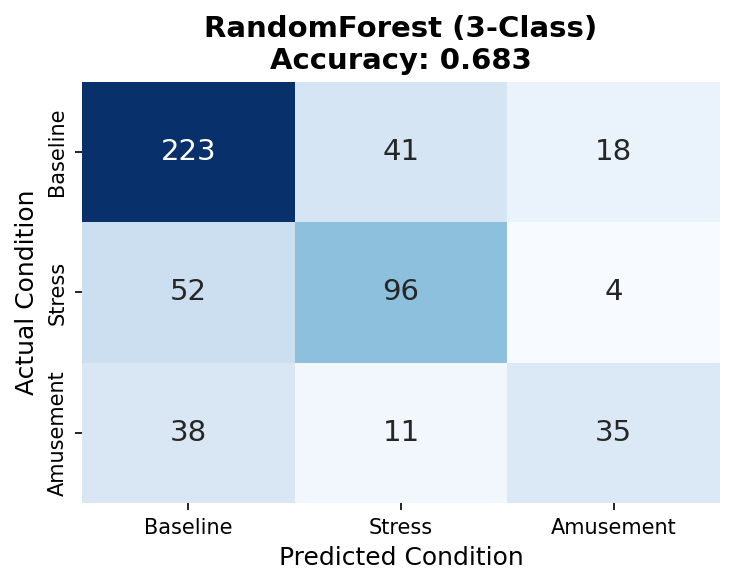

 - SVM         : Acc=0.6853, F1=0.6067


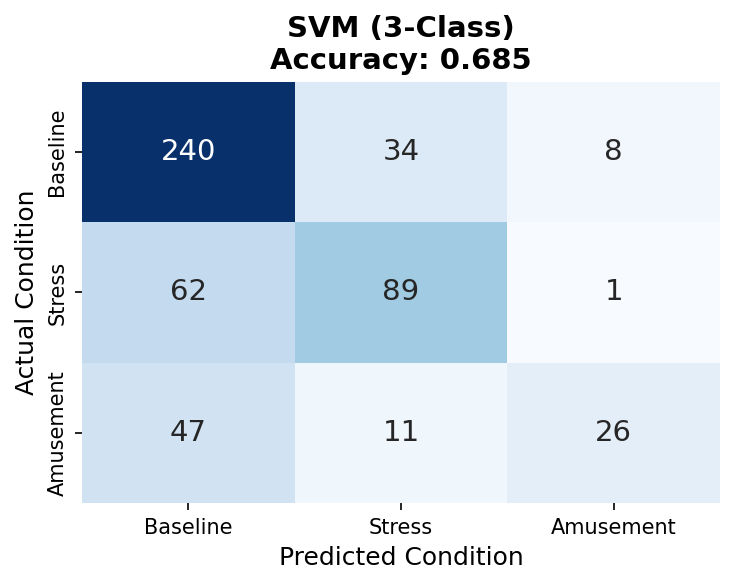

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# ==========================================
# 0. 전역 설정
# ==========================================
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/WESAD-TPV-NoQC.csv'
TPV_COLS = ['TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']
LABEL_COL = 'label_major'
SUBJECT_COL = 'subject'

# ==========================================
# 1. 시각화 유틸리티 (논문용 고해상도)
# ==========================================
def plot_paper_cm(cm, class_names, model_name, acc, task_name):
    """논문에 즉시 삽입 가능한 품질의 혼동 행렬을 그립니다."""
    plt.figure(figsize=(5, 4), dpi=150)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14}, cbar=False)

    plt.title(f'{model_name} ({task_name})\nAccuracy: {acc:.3f}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual Condition', fontsize=12)
    plt.xlabel('Predicted Condition', fontsize=12)
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. 분석 엔진 (LOSO & Personalized)
# ==========================================
class WesadAnalyzer:
    def __init__(self, df):
        self.df = df
        self.models = {
            'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss'),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
            'SVM': SVC(kernel='rbf', probability=True, random_state=42),
            'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
        }

    def run_loso(self, labels, task_name):
        """교차 피험자(LOSO) 평가 수행"""
        print(f"\n[실행 중] {task_name} (LOSO Evaluation)...")
        sub_df = self.df[self.df[LABEL_COL].isin(labels)].copy()
        le = LabelEncoder()
        sub_df['target'] = le.fit_transform(sub_df[LABEL_COL])
        class_names = [str(c) for c in le.classes_]
        # 직관적인 라벨명 (1:Base, 2:Stress, 4:Amuse)
        display_names = [('Baseline' if c=='1' else 'Stress' if c=='2' else 'Amusement') for c in class_names]

        subjects = sorted(sub_df[SUBJECT_COL].unique())
        results = {}

        for m_name, model in self.models.items():
            all_preds, all_trues = [], []
            for test_subj in subjects:
                train_idx = sub_df[SUBJECT_COL] != test_subj
                test_idx = sub_df[SUBJECT_COL] == test_subj

                X_train, X_test = sub_df.loc[train_idx, TPV_COLS], sub_df.loc[test_idx, TPV_COLS]
                y_train, y_test = sub_df.loc[train_idx, 'target'], sub_df.loc[test_idx, 'target']

                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                model.fit(X_train, y_train)
                all_preds.extend(model.predict(X_test))
                all_trues.extend(y_test)

            acc = accuracy_score(all_trues, all_preds)
            f1 = f1_score(all_trues, all_preds, average='macro')
            cm = confusion_matrix(all_trues, all_preds)
            results[m_name] = {'acc': acc, 'f1': f1, 'cm': cm}

            print(f" - {m_name:12}: Acc={acc:.4f}, F1={f1:.4f}")
            plot_paper_cm(cm, display_names, m_name, acc, task_name)

        return results

    def run_personalized(self):
        """각 사용자별 개인화 모델 성능 집계"""
        print(f"\n[실행 중] Personalized (Within-Subject) Evaluation...")
        sub_df = self.df[self.df[LABEL_COL].isin([1, 2, 4])].copy()
        subjects = sorted(sub_df[SUBJECT_COL].unique())

        final_stats = []
        for subj in subjects:
            s_data = sub_df[sub_df[SUBJECT_COL] == subj]
            if len(s_data) < 15: continue # 데이터 부족 샘플 제외

            X = s_data[TPV_COLS]
            y = LabelEncoder().fit_transform(s_data[LABEL_COL])

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # 개인화 모델은 XGBoost 대표로 사용
            model = self.models['XGBoost']
            model.fit(X_train, y_train)
            acc = accuracy_score(y_test, model.predict(X_test))
            final_stats.append(acc)

        print(f" - Personalized Overall Avg Accuracy: {np.mean(final_stats):.4f}")

# ==========================================
# 3. 메인 실행 루프
# ==========================================
if __name__ == "__main__":
    # 데이터 로드
    try:
        raw_df = pd.read_csv(CSV_PATH)
        analyzer = WesadAnalyzer(raw_df)

        # 실험 1: 2진 분류 (Baseline vs Stress)
        analyzer.run_loso(labels=[1, 2], task_name="Binary-Class")

        # 실험 2: 3진 분류 (Baseline vs Stress vs Amusement)
        analyzer.run_loso(labels=[1, 2, 4], task_name="3-Class")

        # 실험 3: 개인화 모델 분석
        analyzer.run_personalized()

    except FileNotFoundError:
        print("CSV 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

데이터 로드 성공!


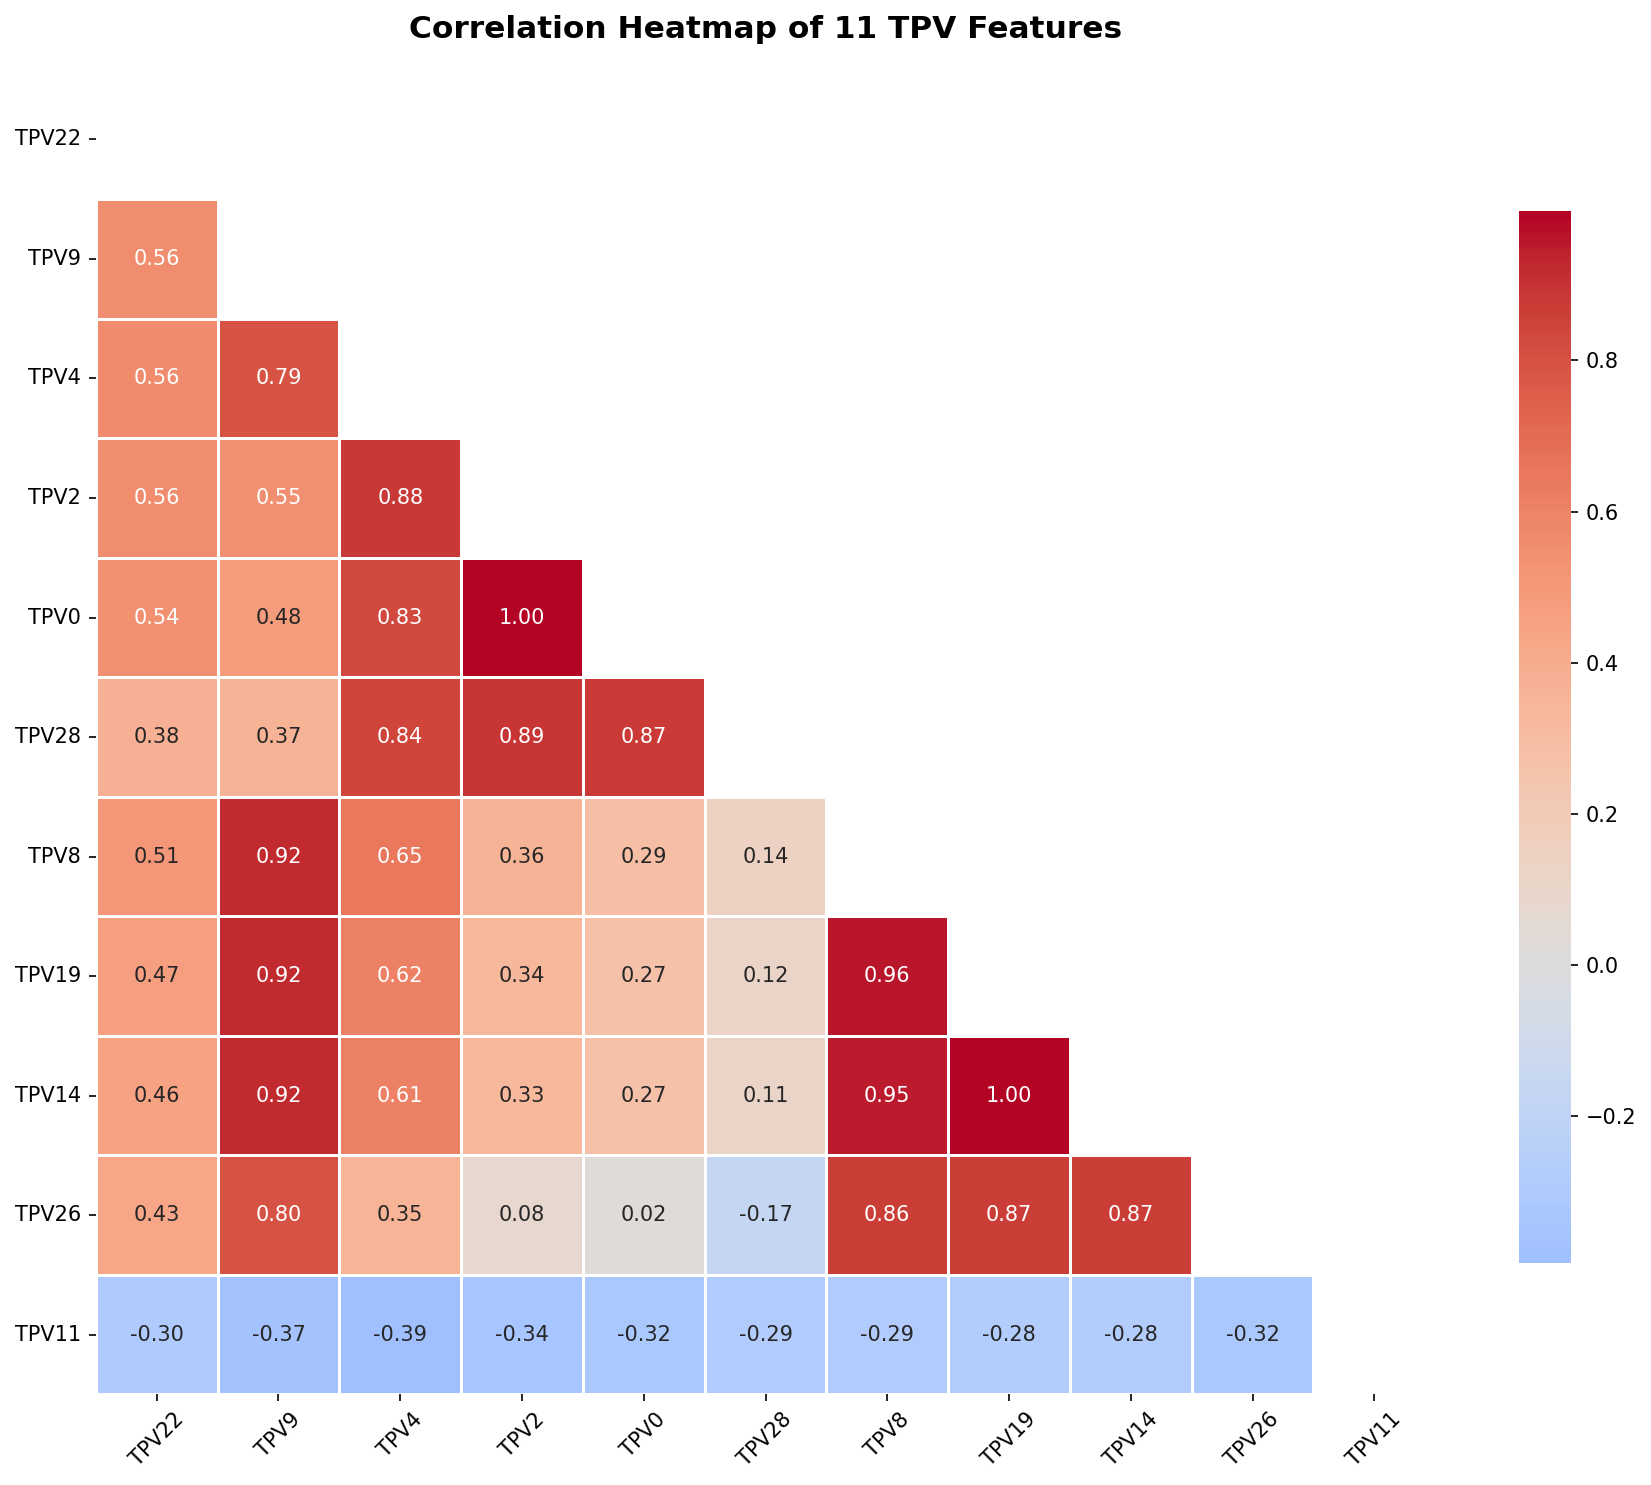

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 (경로를 본인의 환경에 맞게 수정하세요)
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/WESAD-TPV-NoQC.csv'

try:
    df = pd.read_csv(CSV_PATH)
    print("데이터 로드 성공!")

    # 분석에 사용할 TPV 컬럼 정의
    TPV_COLS = ['TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']

    # 2. 상관관계 히트맵 함수 정의
    def plot_feature_correlation(data, features):
        """
        11개 TPV 피처 간의 피어슨 상관계수를 계산하여 히트맵으로 시각화합니다.
        """
        # 상관계수 행렬 계산
        corr_matrix = data[features].corr()

        # 히트맵 시각화 설정 (논문용 고해상도)
        plt.figure(figsize=(12, 10), dpi=150)

        # 마스크 설정 (대칭형이므로 윗부분을 가려 가독성 높임)
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # 히트맵 그리기
        sns.heatmap(
            corr_matrix,
            mask=mask,
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째 자리까지
            cmap='coolwarm',     # 파랑(음의 상관) ~ 빨강(양의 상관)
            center=0,            # 0을 기준으로 색상 배분
            linewidths=.5,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 10}
        )

        plt.title('Correlation Heatmap of 11 TPV Features', fontsize=15, fontweight='bold', pad=20)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # 3. 함수 실행
    plot_feature_correlation(df, TPV_COLS)

except FileNotFoundError:
    print(f"에러: '{CSV_PATH}' 경로에서 파일을 찾을 수 없습니다. 경로를 다시 확인해 주세요.")
except Exception as e:
    print(f"에러 발생: {e}")

Starting Binary CNN LOSO (Baseline vs Stress) on 15 subjects...
Fold 01 | Subject S10 | Acc: 0.7000
Fold 02 | Subject S11 | Acc: 0.8000
Fold 03 | Subject S13 | Acc: 0.7241
Fold 04 | Subject S14 | Acc: 0.8621
Fold 05 | Subject S15 | Acc: 0.6667
Fold 06 | Subject S16 | Acc: 0.6552
Fold 07 | Subject S17 | Acc: 0.9000
Fold 08 | Subject S2 | Acc: 0.7500
Fold 09 | Subject S3 | Acc: 0.8214
Fold 10 | Subject S4 | Acc: 0.9643
Fold 11 | Subject S5 | Acc: 0.9286
Fold 12 | Subject S6 | Acc: 0.6207
Fold 13 | Subject S7 | Acc: 0.8621
Fold 14 | Subject S8 | Acc: 0.8000
Fold 15 | Subject S9 | Acc: 0.7778

BINARY CNN LOSO RESULTS
Final Accuracy : 0.7880
Final F1-Score : 0.7537


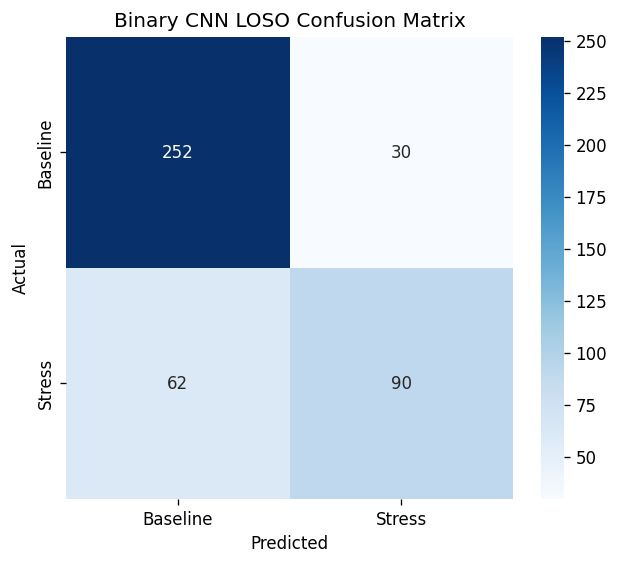

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. 2진 분류용 1D-CNN 모델 설계
# ==========================================
class BinaryCNN1D(nn.Module):
    def __init__(self, in_features=11):
        super(BinaryCNN1D, self).__init__()
        # 11개의 피처를 1차원 신호로 처리
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # 특징 요약
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 2) # 2진 분류 (Baseline vs Stress)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1) # (Batch, 11) -> (Batch, 1, 11)
        x = self.features(x)
        return self.classifier(x)

# ==========================================
# 2. LOSO 2진 분류 실행 엔진
# ==========================================
def run_binary_cnn_loso(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Baseline(1)과 Stress(2) 데이터만 추출
    sub_df = df[df['label_major'].isin([1, 2])].copy()

    # 라벨 인코딩 (1 -> 0, 2 -> 1)
    le = LabelEncoder()
    sub_df['target'] = le.fit_transform(sub_df['label_major'])
    subjects = sorted(sub_df['subject'].unique())

    all_preds, all_trues = [], []
    print(f"Starting Binary CNN LOSO (Baseline vs Stress) on {len(subjects)} subjects...")

    for i, test_subj in enumerate(subjects):
        # 데이터 분할
        train_data = sub_df[sub_df['subject'] != test_subj]
        test_data = sub_df[sub_df['subject'] == test_subj]

        X_train = train_data[features].values.astype(np.float32)
        y_train = train_data['target'].values
        X_test = test_data[features].values.astype(np.float32)
        y_test = test_data['target'].values

        # 스케일링
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # DataLoader
        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

        # 모델 초기화
        model = BinaryCNN1D(in_features=len(features)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

        # 학습
        model.train()
        for epoch in range(30):
            for bx, by in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx.to(device)), by.to(device))
                loss.backward()
                optimizer.step()

        # 테스트
        model.eval()
        with torch.no_grad():
            test_outputs = model(torch.FloatTensor(X_test).to(device))
            preds = test_outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(y_test)

        fold_acc = accuracy_score(y_test, preds)
        print(f"Fold {i+1:02d} | Subject {test_subj} | Acc: {fold_acc:.4f}")

    # 결과 통계
    final_acc = accuracy_score(all_trues, all_preds)
    final_f1 = f1_score(all_trues, all_preds, average='macro')

    print(f"\n{'='*40}")
    print(f"BINARY CNN LOSO RESULTS")
    print(f"Final Accuracy : {final_acc:.4f}")
    print(f"Final F1-Score : {final_f1:.4f}")
    print(f"{'='*40}")

    # 혼동 행렬 시각화
    cm = confusion_matrix(all_trues, all_preds)
    plt.figure(figsize=(6, 5), dpi=120)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baseline', 'Stress'],
                yticklabels=['Baseline', 'Stress'])
    plt.title('Binary CNN LOSO Confusion Matrix', fontsize=12)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 실행 (기존 df가 정의되어 있어야 함)
run_binary_cnn_loso(df, TPV_COLS)

Starting Improved Binary CNN LOSO | Device: cuda
Fold 01 | Sub: S10 | Acc: 0.6667
Fold 02 | Sub: S11 | Acc: 0.8000
Fold 03 | Sub: S13 | Acc: 0.7241
Fold 04 | Sub: S14 | Acc: 0.9310
Fold 05 | Sub: S15 | Acc: 0.6000
Fold 06 | Sub: S16 | Acc: 0.6552
Fold 07 | Sub: S17 | Acc: 0.8667
Fold 08 | Sub: S2 | Acc: 0.7500
Fold 09 | Sub: S3 | Acc: 0.7500
Fold 10 | Sub: S4 | Acc: 0.9643
Fold 11 | Sub: S5 | Acc: 0.8571
Fold 12 | Sub: S6 | Acc: 0.6207
Fold 13 | Sub: S7 | Acc: 0.8276
Fold 14 | Sub: S8 | Acc: 0.8667
Fold 15 | Sub: S9 | Acc: 0.6667

FINAL CONSOLIDATED RESULTS
              precision    recall  f1-score   support

    Baseline       0.82      0.82      0.82       282
      Stress       0.67      0.67      0.67       152

    accuracy                           0.77       434
   macro avg       0.75      0.75      0.75       434
weighted avg       0.77      0.77      0.77       434



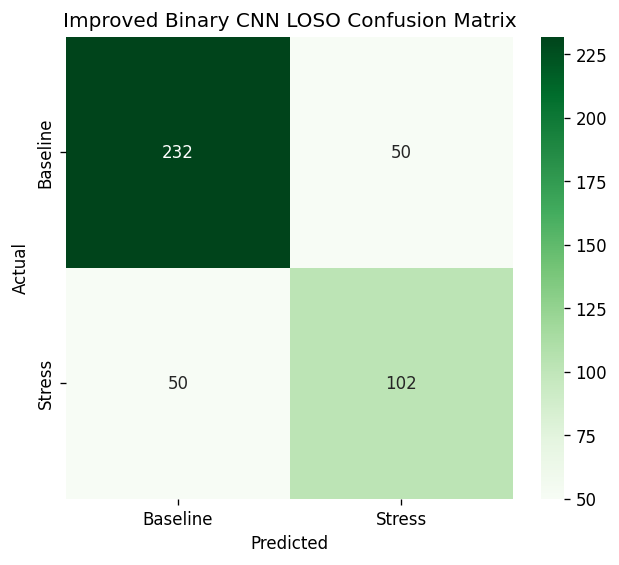

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/WESAD-TPV-NoQC.csv'
TPV_COLS = ['TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']
LABEL_COL = 'label_major'
SUBJECT_COL = 'subject'

# ==========================================
# 2. 모델 설계 (일반화 성능 강화형)
# ==========================================
class RobustBinaryCNN(nn.Module):
    def __init__(self, in_features=11):
        super(RobustBinaryCNN, self).__init__()
        self.features = nn.Sequential(
            # 채널 수를 조절하고 드롭아웃을 강화하여 과적합 방지
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.classifier(self.features(x))

# ==========================================
# 3. LOSO 학습 및 평가 엔진 (Weighted Loss 적용)
# ==========================================
def run_improved_cnn_loso(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 2진 분류 데이터 필터링 (1: Baseline, 2: Stress)
    sub_df = df[df[LABEL_COL].isin([1, 2])].copy()
    le = LabelEncoder()
    sub_df['target'] = le.fit_transform(sub_df[LABEL_COL])
    subjects = sorted(sub_df[SUBJECT_COL].unique())

    all_preds, all_trues = [], []
    print(f"Starting Improved Binary CNN LOSO | Device: {device}")

    for i, test_subj in enumerate(subjects):
        # 데이터 분할
        train_data = sub_df[sub_df[SUBJECT_COL] != test_subj]
        test_data = sub_df[sub_df[SUBJECT_COL] == test_subj]

        X_train = train_data[features].values.astype(np.float32)
        y_train = train_data['target'].values
        X_test = test_data[features].values.astype(np.float32)
        y_test = test_data['target'].values

        # 스케일링
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # 클래스 가중치 계산 (데이터 불균형 해결의 핵심)
        class_counts = np.bincount(y_train)
        weights = 1. / torch.tensor(class_counts, dtype=torch.float)
        weights = (weights / weights.sum()).to(device) # 가중치 정규화

        # DataLoader
        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
        train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

        # 모델 초기화
        model = RobustBinaryCNN(in_features=len(features)).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights) # 가중 손실 함수 적용
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)

        # 학습
        model.train()
        for epoch in range(40):
            for bx, by in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx.to(device)), by.to(device))
                loss.backward()
                optimizer.step()

        # 테스트
        model.eval()
        with torch.no_grad():
            preds = model(torch.FloatTensor(X_test).to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(y_test)

        fold_acc = accuracy_score(y_test, preds)
        print(f"Fold {i+1:02d} | Sub: {test_subj} | Acc: {fold_acc:.4f}")

    # 최종 결과 리포트
    print("\n" + "="*50)
    print("FINAL CONSOLIDATED RESULTS")
    print("="*50)
    print(classification_report(all_trues, all_preds, target_names=['Baseline', 'Stress']))

    # 혼동 행렬 시각화
    cm = confusion_matrix(all_trues, all_preds)
    plt.figure(figsize=(6, 5), dpi=120)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Baseline', 'Stress'], yticklabels=['Baseline', 'Stress'])
    plt.title('Improved Binary CNN LOSO Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# ==========================================
# 4. 실행
# ==========================================
# df = pd.read_csv(CSV_PATH) # 이미 로드되어 있다면 생략 가능
run_improved_cnn_loso(df, TPV_COLS)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 개인화 전용 1D-CNN 구조
# ==========================================
class PersonalizedCNN(nn.Module):
    def __init__(self, in_features=11):
        super(PersonalizedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.classifier(self.features(x))

# ==========================================
# 2. 개인화 학습 및 평가 루틴
# ==========================================
def run_personalized_cnn(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 2진 분류 데이터 필터링 (1: Base, 2: Stress)
    sub_df = df[df['label_major'].isin([1, 2])].copy()
    le = LabelEncoder()
    sub_df['target'] = le.fit_transform(sub_df['label_major'])

    subjects = sorted(sub_df['subject'].unique())
    all_results = []

    print(f"{'Subject':<10} | {'Train Size':<12} | {'Test Size':<12} | {'Accuracy':<10}")
    print("-" * 55)

    for subj in subjects:
        # 특정 피험자 데이터만 추출
        subj_data = sub_df[sub_df['subject'] == subj]
        X = subj_data[features].values.astype(np.float32)
        y = subj_data['target'].values

        if len(subj_data) < 10: continue

        # [핵심] 해당 피험자의 데이터를 Train/Test로 분할
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # 해당 피험자 데이터에 맞춤 스케일링
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # DataLoader
        train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
        train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

        # 모델 학습
        model = PersonalizedCNN(in_features=len(features)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        model.train()
        for epoch in range(50): # 개인 데이터는 양이 적어 금방 학습됨
            for bx, by in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx.to(device)), by.to(device))
                loss.backward()
                optimizer.step()

        # 평가
        model.eval()
        with torch.no_grad():
            preds = model(torch.FloatTensor(X_test).to(device)).argmax(1).cpu().numpy()

        acc = accuracy_score(y_test, preds)
        all_results.append(acc)
        print(f"{subj:<10} | {len(X_train):<12} | {len(X_test):<12} | {acc:<10.4f}")

    print("-" * 55)
    print(f"OVERALL PERSONALIZED AVG ACC: {np.mean(all_results):.4f}")

# 실행
run_personalized_cnn(df, TPV_COLS)

Subject    | Train Size   | Test Size    | Accuracy  
-------------------------------------------------------
S10        | 24           | 6            | 0.6667    
S11        | 24           | 6            | 0.8333    
S13        | 23           | 6            | 0.5000    
S14        | 23           | 6            | 1.0000    
S15        | 24           | 6            | 0.5000    
S16        | 23           | 6            | 0.6667    
S17        | 24           | 6            | 1.0000    
S2         | 22           | 6            | 0.6667    
S3         | 22           | 6            | 0.6667    
S4         | 22           | 6            | 1.0000    
S5         | 22           | 6            | 0.8333    
S6         | 23           | 6            | 0.8333    
S7         | 23           | 6            | 0.8333    
S8         | 24           | 6            | 1.0000    
S9         | 21           | 6            | 0.5000    
-------------------------------------------------------
OVERALL PERSONALIZED AVG

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 모델 아키텍처 (Pre-train & Fine-tune 공용)
# ==========================================
class WesadFineTuneCNN(nn.Module):
    def __init__(self, in_features=11):
        super(WesadFineTuneCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.classifier(self.features(x))

# ==========================================
# 2. Fine-tuning 실행 엔진
# ==========================================
def run_finetuned_cnn_system(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 데이터 필터링 (1: Baseline, 2: Stress)
    sub_df = df[df['label_major'].isin([1, 2])].copy()
    le = LabelEncoder()
    sub_df['target'] = le.fit_transform(sub_df['label_major'])
    subjects = sorted(sub_df['subject'].unique())

    total_results = []
    print(f"Starting Fine-tuning CNN System | Total Subjects: {len(subjects)}")
    print("-" * 60)
    print(f"{'Subject':<10} | {'Pre-train Acc':<15} | {'Fine-tuned Acc':<15}")
    print("-" * 60)

    for test_subj in subjects:
        # --- PHASE 1: Pre-training (타인들의 데이터로 학습) ---
        train_others = sub_df[sub_df['subject'] != test_subj]
        X_pre = train_others[features].values.astype(np.float32)
        y_pre = train_others['target'].values

        scaler_pre = StandardScaler()
        X_pre = scaler_pre.fit_transform(X_pre)

        pre_ds = TensorDataset(torch.FloatTensor(X_pre), torch.LongTensor(y_pre))
        pre_loader = DataLoader(pre_ds, batch_size=64, shuffle=True)

        model = WesadFineTuneCNN(in_features=len(features)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # 선학습 (다른 사람들의 보편적 패턴 습득)
        model.train()
        for epoch in range(20):
            for bx, by in pre_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx.to(device)), by.to(device))
                loss.backward()
                optimizer.step()

        # --- PHASE 2: Baseline 평가 (Fine-tuning 전 성능) ---
        subj_data = sub_df[sub_df['subject'] == test_subj]
        X_s = subj_data[features].values.astype(np.float32)
        y_s = subj_data['target'].values

        X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

        scaler_subj = StandardScaler().fit(X_tr)
        X_te_scaled = torch.FloatTensor(scaler_subj.transform(X_te)).to(device)

        model.eval()
        with torch.no_grad():
            pre_preds = model(X_te_scaled).argmax(1).cpu().numpy()
            pre_acc = accuracy_score(y_te, pre_preds)

        # --- PHASE 3: Fine-tuning (해당 피험자 데이터로 미세 조정) ---
        ft_ds = TensorDataset(torch.FloatTensor(scaler_subj.transform(X_tr)), torch.LongTensor(y_tr))
        ft_loader = DataLoader(ft_ds, batch_size=4, shuffle=True)

        # 학습률을 낮게 설정하여 기존 지식을 보존하며 개인화
        optimizer = optim.Adam(model.parameters(), lr=0.0001)

        model.train()
        for epoch in range(15):
            for bx, by in ft_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx.to(device)), by.to(device))
                loss.backward()
                optimizer.step()

        # --- PHASE 4: 최종 평가 ---
        model.eval()
        with torch.no_grad():
            ft_preds = model(X_te_scaled).argmax(1).cpu().numpy()
            ft_acc = accuracy_score(y_te, ft_preds)

        total_results.append(ft_acc)
        print(f"{test_subj:<10} | {pre_acc:<15.4f} | {ft_acc:<15.4f}")

    print("-" * 60)
    print(f"FINAL SYSTEM AVG ACCURACY: {np.mean(total_results):.4f}")

# 실행 (df가 로드된 상태여야 함)
run_finetuned_cnn_system(df, TPV_COLS)

Starting Fine-tuning CNN System | Total Subjects: 15
------------------------------------------------------------
Subject    | Pre-train Acc   | Fine-tuned Acc 
------------------------------------------------------------
S10        | 0.6667          | 0.6667         
S11        | 1.0000          | 1.0000         
S13        | 0.5000          | 0.5000         
S14        | 1.0000          | 1.0000         
S15        | 0.5000          | 0.5000         
S16        | 0.6667          | 0.8333         
S17        | 1.0000          | 1.0000         
S2         | 0.8333          | 0.8333         
S3         | 0.8333          | 0.8333         
S4         | 1.0000          | 1.0000         
S5         | 0.6667          | 0.6667         
S6         | 0.6667          | 0.6667         
S7         | 0.6667          | 0.6667         
S8         | 0.8333          | 0.8333         
S9         | 0.6667          | 0.5000         
------------------------------------------------------------
FINAL SYSTEM

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 증강 함수 (Noise Injection)
# ==========================================
def inject_noise(data, noise_level=0.05):
    """원본 데이터에 미세한 가우시안 노이즈를 추가합니다."""
    noise = np.random.normal(0, noise_level, data.shape)
    return (data + noise).astype(np.float32)

# ==========================================
# 2. 모델 아키텍처
# ==========================================
class AugmentedCNN(nn.Module):
    def __init__(self, in_features=11):
        super(AugmentedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        return self.classifier(self.features(x))

# ==========================================
# 3. 개선된 Fine-tuning 엔진
# ==========================================
def run_augmented_cnn_system(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 2진 분류 데이터 필터링
    sub_df = df[df['label_major'].isin([1, 2])].copy()
    le = LabelEncoder()
    sub_df['target'] = le.fit_transform(sub_df['label_major'])
    subjects = sorted(sub_df['subject'].unique())

    total_results = []
    print(f"Starting Augmented Fine-tuning CNN | Subjects: {len(subjects)}")
    print("-" * 60)

    for test_subj in subjects:
        # --- PHASE 1: Pre-training (타인 데이터) ---
        train_others = sub_df[sub_df['subject'] != test_subj]
        X_pre = train_others[features].values.astype(np.float32)
        y_pre = train_others['target'].values

        scaler_pre = StandardScaler()
        X_pre = scaler_pre.fit_transform(X_pre)

        pre_ds = TensorDataset(torch.FloatTensor(X_pre), torch.LongTensor(y_pre))
        pre_loader = DataLoader(pre_ds, batch_size=64, shuffle=True)

        model = AugmentedCNN(in_features=len(features)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(20):
            for bx, by in pre_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                outputs = model(bx)
                loss = criterion(outputs, by)
                loss.backward()
                optimizer.step()

        # --- PHASE 2: Fine-tuning with Data Augmentation ---
        subj_data = sub_df[sub_df['subject'] == test_subj]
        X_s = subj_data[features].values.astype(np.float32)
        y_s = subj_data['target'].values

        X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)
        scaler_subj = StandardScaler().fit(X_tr)
        X_tr_scaled = scaler_subj.transform(X_tr)

        # 데이터 증강: 원본 + 노이즈 데이터 (데이터 2배 확보)
        X_tr_aug = np.vstack([X_tr_scaled, inject_noise(X_tr_scaled)])
        y_tr_aug = np.concatenate([y_tr, y_tr])

        ft_ds = TensorDataset(torch.FloatTensor(X_tr_aug), torch.LongTensor(y_tr_aug))
        ft_loader = DataLoader(ft_ds, batch_size=4, shuffle=True)

        # 학습률을 낮추어 미세 조정
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        model.train()
        for epoch in range(15):
            for bx, by in ft_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                outputs = model(bx)
                loss = criterion(outputs, by)
                loss.backward()
                optimizer.step()

        # --- PHASE 3: 최종 평가 ---
        model.eval()
        with torch.no_grad():
            X_te_t = torch.FloatTensor(scaler_subj.transform(X_te)).to(device)
            preds = model(X_te_t).argmax(1).cpu().numpy()
            acc = accuracy_score(y_te, preds)

        total_results.append(acc)
        print(f"Subject {test_subj} | Augmented Acc: {acc:.4f}")

    print("-" * 60)
    print(f"FINAL AUGMENTED AVG ACCURACY: {np.mean(total_results):.4f}")

# 실행
run_augmented_cnn_system(df, TPV_COLS)

Starting Augmented Fine-tuning CNN | Subjects: 15
------------------------------------------------------------
Subject S10 | Augmented Acc: 0.6667
Subject S11 | Augmented Acc: 1.0000
Subject S13 | Augmented Acc: 0.5000
Subject S14 | Augmented Acc: 1.0000
Subject S15 | Augmented Acc: 0.5000
Subject S16 | Augmented Acc: 0.8333
Subject S17 | Augmented Acc: 1.0000
Subject S2 | Augmented Acc: 0.8333
Subject S3 | Augmented Acc: 0.6667
Subject S4 | Augmented Acc: 1.0000
Subject S5 | Augmented Acc: 0.6667
Subject S6 | Augmented Acc: 0.6667
Subject S7 | Augmented Acc: 0.6667
Subject S8 | Augmented Acc: 0.8333
Subject S9 | Augmented Acc: 0.6667
------------------------------------------------------------
FINAL AUGMENTED AVG ACCURACY: 0.7667


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 논문용 정제된 피처 리스트 (8개)
# ==========================================
# 히트맵 분석 결과 중복(corr=1.0) 및 과잉 피처 제거
REFINED_FEATURES = ['TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV28', 'TPV8', 'TPV26', 'TPV11']

# ==========================================
# 2. 데이터 증강 및 모델 정의
# ==========================================
def inject_noise(data, noise_level=0.03):
    return (data + np.random.normal(0, noise_level, data.shape)).astype(np.float32)

class FinalResearchCNN(nn.Module):
    def __init__(self, in_features=8):
        super(FinalResearchCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(1)
        return self.classifier(self.features(x))

# ==========================================
# 3. 통합 실행 엔진
# ==========================================
def run_final_paper_system(df, features):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    sub_df = df[df['label_major'].isin([1, 2])].copy()
    le = LabelEncoder()
    sub_df['target'] = le.fit_transform(sub_df['label_major'])
    subjects = sorted(sub_df['subject'].unique())

    total_acc, total_f1 = [], []
    print(f"Final Research System | Features: {len(features)} | Subjects: {len(subjects)}")
    print("-" * 65)

    for test_subj in subjects:
        # --- Pre-train ---
        train_others = sub_df[sub_df['subject'] != test_subj]
        X_pre = StandardScaler().fit_transform(train_others[features].values.astype(np.float32))
        y_pre = train_others['target'].values

        pre_loader = DataLoader(TensorDataset(torch.FloatTensor(X_pre), torch.LongTensor(y_pre)), batch_size=64, shuffle=True)
        model = FinalResearchCNN(in_features=len(features)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for _ in range(20):
            for bx, by in pre_loader:
                optimizer.zero_grad(); loss = criterion(model(bx.to(device)), by.to(device)); loss.backward(); optimizer.step()

        # --- Fine-tune with Augmentation ---
        subj_data = sub_df[sub_df['subject'] == test_subj]
        X_s = subj_data[features].values.astype(np.float32)
        y_s = subj_data['target'].values
        X_tr, X_te, y_tr, y_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_tr_aug = np.vstack([X_tr_s, inject_noise(X_tr_s)])
        y_tr_aug = np.concatenate([y_tr, y_tr])

        ft_loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr_aug), torch.LongTensor(y_tr_aug)), batch_size=4, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=0.0001)

        model.train()
        for _ in range(15):
            for bx, by in ft_loader:
                optimizer.zero_grad(); loss = criterion(model(bx.to(device)), by.to(device)); loss.backward(); optimizer.step()

        # --- Evaluation ---
        model.eval()
        with torch.no_grad():
            preds = model(torch.FloatTensor(scaler.transform(X_te)).to(device)).argmax(1).cpu().numpy()
            acc = accuracy_score(y_te, preds)
            f1 = f1_score(y_te, preds, average='macro')

        total_acc.append(acc); total_f1.append(f1)
        print(f"Sub {test_subj} | Acc: {acc:.4f} | F1: {f1:.4f}")

    print("-" * 65)
    print(f"FINAL PAPER AVG ACC: {np.mean(total_acc):.4f}")
    print(f"FINAL PAPER AVG F1:  {np.mean(total_f1):.4f}")

# 실행
run_final_paper_system(df, REFINED_FEATURES)

Final Research System | Features: 8 | Subjects: 15
-----------------------------------------------------------------
Sub S10 | Acc: 0.6667 | F1: 0.6250
Sub S11 | Acc: 1.0000 | F1: 1.0000
Sub S13 | Acc: 0.6667 | F1: 0.6250
Sub S14 | Acc: 1.0000 | F1: 1.0000
Sub S15 | Acc: 0.5000 | F1: 0.4857
Sub S16 | Acc: 0.8333 | F1: 0.7778
Sub S17 | Acc: 1.0000 | F1: 1.0000
Sub S2 | Acc: 0.8333 | F1: 0.7778
Sub S3 | Acc: 0.8333 | F1: 0.7778
Sub S4 | Acc: 1.0000 | F1: 1.0000
Sub S5 | Acc: 0.8333 | F1: 0.8286
Sub S6 | Acc: 0.6667 | F1: 0.4000
Sub S7 | Acc: 0.6667 | F1: 0.6667
Sub S8 | Acc: 0.8333 | F1: 0.7778
Sub S9 | Acc: 0.6667 | F1: 0.6250
-----------------------------------------------------------------
FINAL PAPER AVG ACC: 0.8000
FINAL PAPER AVG F1:  0.7578


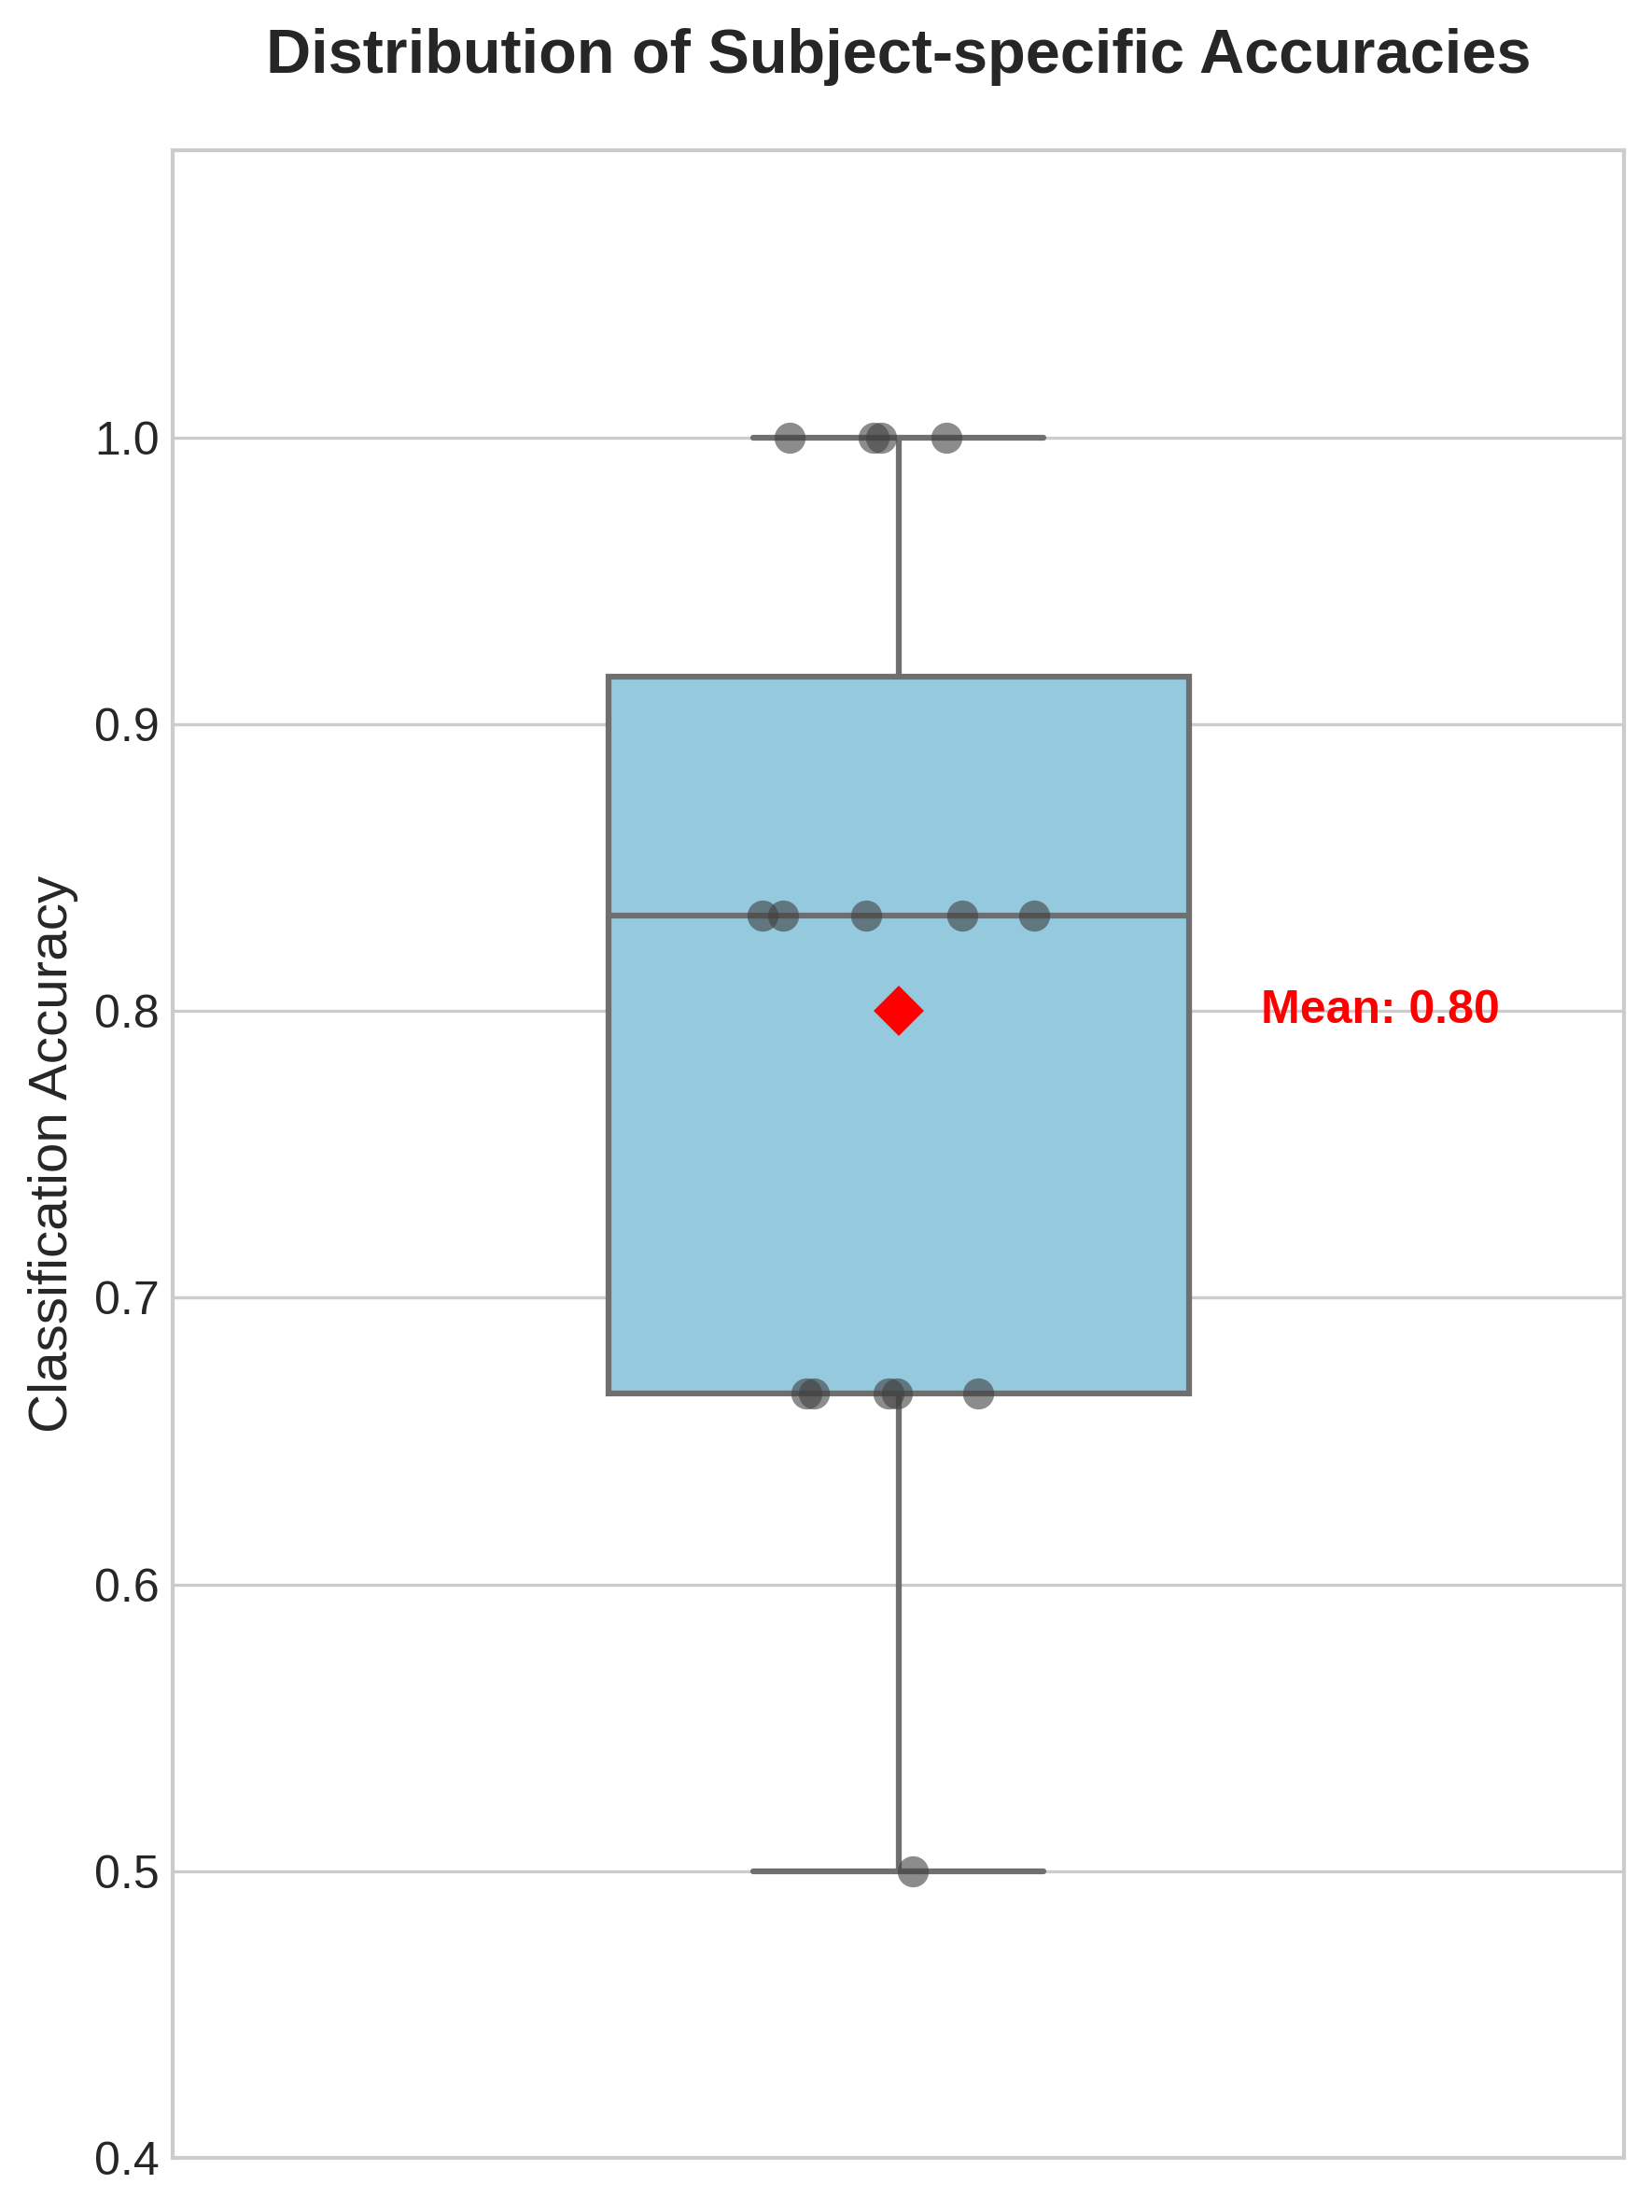

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 실험 결과 데이터 생성
results_data = {
    'Subject': ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9'],
    'Accuracy': [0.6667, 1.0000, 0.6667, 1.0000, 0.5000, 0.8333, 1.0000, 0.8333, 0.8333, 1.0000, 0.8333, 0.6667, 0.6667, 0.8333, 0.6667]
}
df_res = pd.DataFrame(results_data)

# 2. 그래프 스타일 설정 (논문용)
plt.style.use('seaborn-v0_8-whitegrid') # 깔끔한 화이트 그리드
fig, ax = plt.subplots(figsize=(6, 8), dpi=300) # 고해상도 설정

# 3. Boxplot 그리기
sns.boxplot(
    y='Accuracy',
    data=df_res,
    width=0.4,
    color='skyblue',
    linewidth=1.5,
    showmeans=True, # 평균값(녹색 삼각형) 표시
    meanprops={"marker":"D", "markerfacecolor":"red", "markeredgecolor":"red", "markersize":8}, # 평균은 빨간 다이아몬드로 강조
    ax=ax
)

# 4. Strip plot 추가 (개별 피험자 점들을 겹쳐서 투명하게 공개)
sns.stripplot(
    y='Accuracy',
    data=df_res,
    size=8,
    color=".25",
    linewidth=0,
    alpha=0.6,
    jitter=True, # 점들이 겹치지 않게 좌우로 흩뿌림
    ax=ax
)

# 5. 그래프 디테일 조정 (폰트 크기 및 라벨)
ax.set_title('Distribution of Subject-specific Accuracies', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Classification Accuracy', fontsize=14)
ax.set_ylim(0.4, 1.1) # 가독성을 위해 y축 범위 조정
plt.yticks(np.arange(0.4, 1.1, 0.1), fontsize=12)

# 6. 평균값 텍스트 표시
mean_val = df_res['Accuracy'].mean()
ax.text(0.25, mean_val, f'Mean: {mean_val:.2f}', color='red', fontweight='bold', fontsize=12, va='center')

plt.tight_layout()

# 7. 파일 저장 (PDF 또는 TIFF는 논문 투고 시 깨지지 않습니다)
# plt.savefig('accuracy_boxplot.pdf', bbox_inches='tight')
plt.show()